# Problem Statement:
 Use a relevant machine learinig model to predict house prices based on different features of the houses.










In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [2]:
data=pd.read_csv('/content/data.csv')
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
data.head(pd.set_option('display.max_columns',None))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [4]:
data1=data.copy()

In [5]:
data1.drop('Id',axis=1,inplace=True)


In [6]:
data1

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,

# Domain Analysis

The dataset contains detailed information about residential homes .

It includes structural, location, and quality-related features to predict house sale prices.


# **Basic checks**

In [7]:
data1.shape

(1460, 80)

In [8]:
data1.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
data1.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [10]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [11]:
data1.dtypes

,0
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [12]:
data1.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [13]:
data1.describe(include='O').T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [14]:
# To fetch numercial columns
num_col=data1.select_dtypes(include=np.number).columns
num_col

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [15]:
# To fetch categorical columns
cat_col=data1.select_dtypes(include='object')
cat_col.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [16]:
#find unique categories in categorial columns using loop
for i in cat_col:
    print(i,data1[i].unique())
    print(i,data1[i].value_counts())
    print('*******************************************')

MSZoning ['RL' 'RM' 'C (all)' 'FV' 'RH']
MSZoning MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
*******************************************
Street ['Pave' 'Grvl']
Street Street
Pave    1454
Grvl       6
Name: count, dtype: int64
*******************************************
Alley [nan 'Grvl' 'Pave']
Alley Alley
Grvl    50
Pave    41
Name: count, dtype: int64
*******************************************
LotShape ['Reg' 'IR1' 'IR2' 'IR3']
LotShape LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
*******************************************
LandContour ['Lvl' 'Bnk' 'Low' 'HLS']
LandContour LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
*******************************************
Utilities ['AllPub' 'NoSeWa']
Utilities Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
*******************************************
LotConfig ['Inside' 'FR2' 'Corn

# **EDA**

Bivariate Analysis

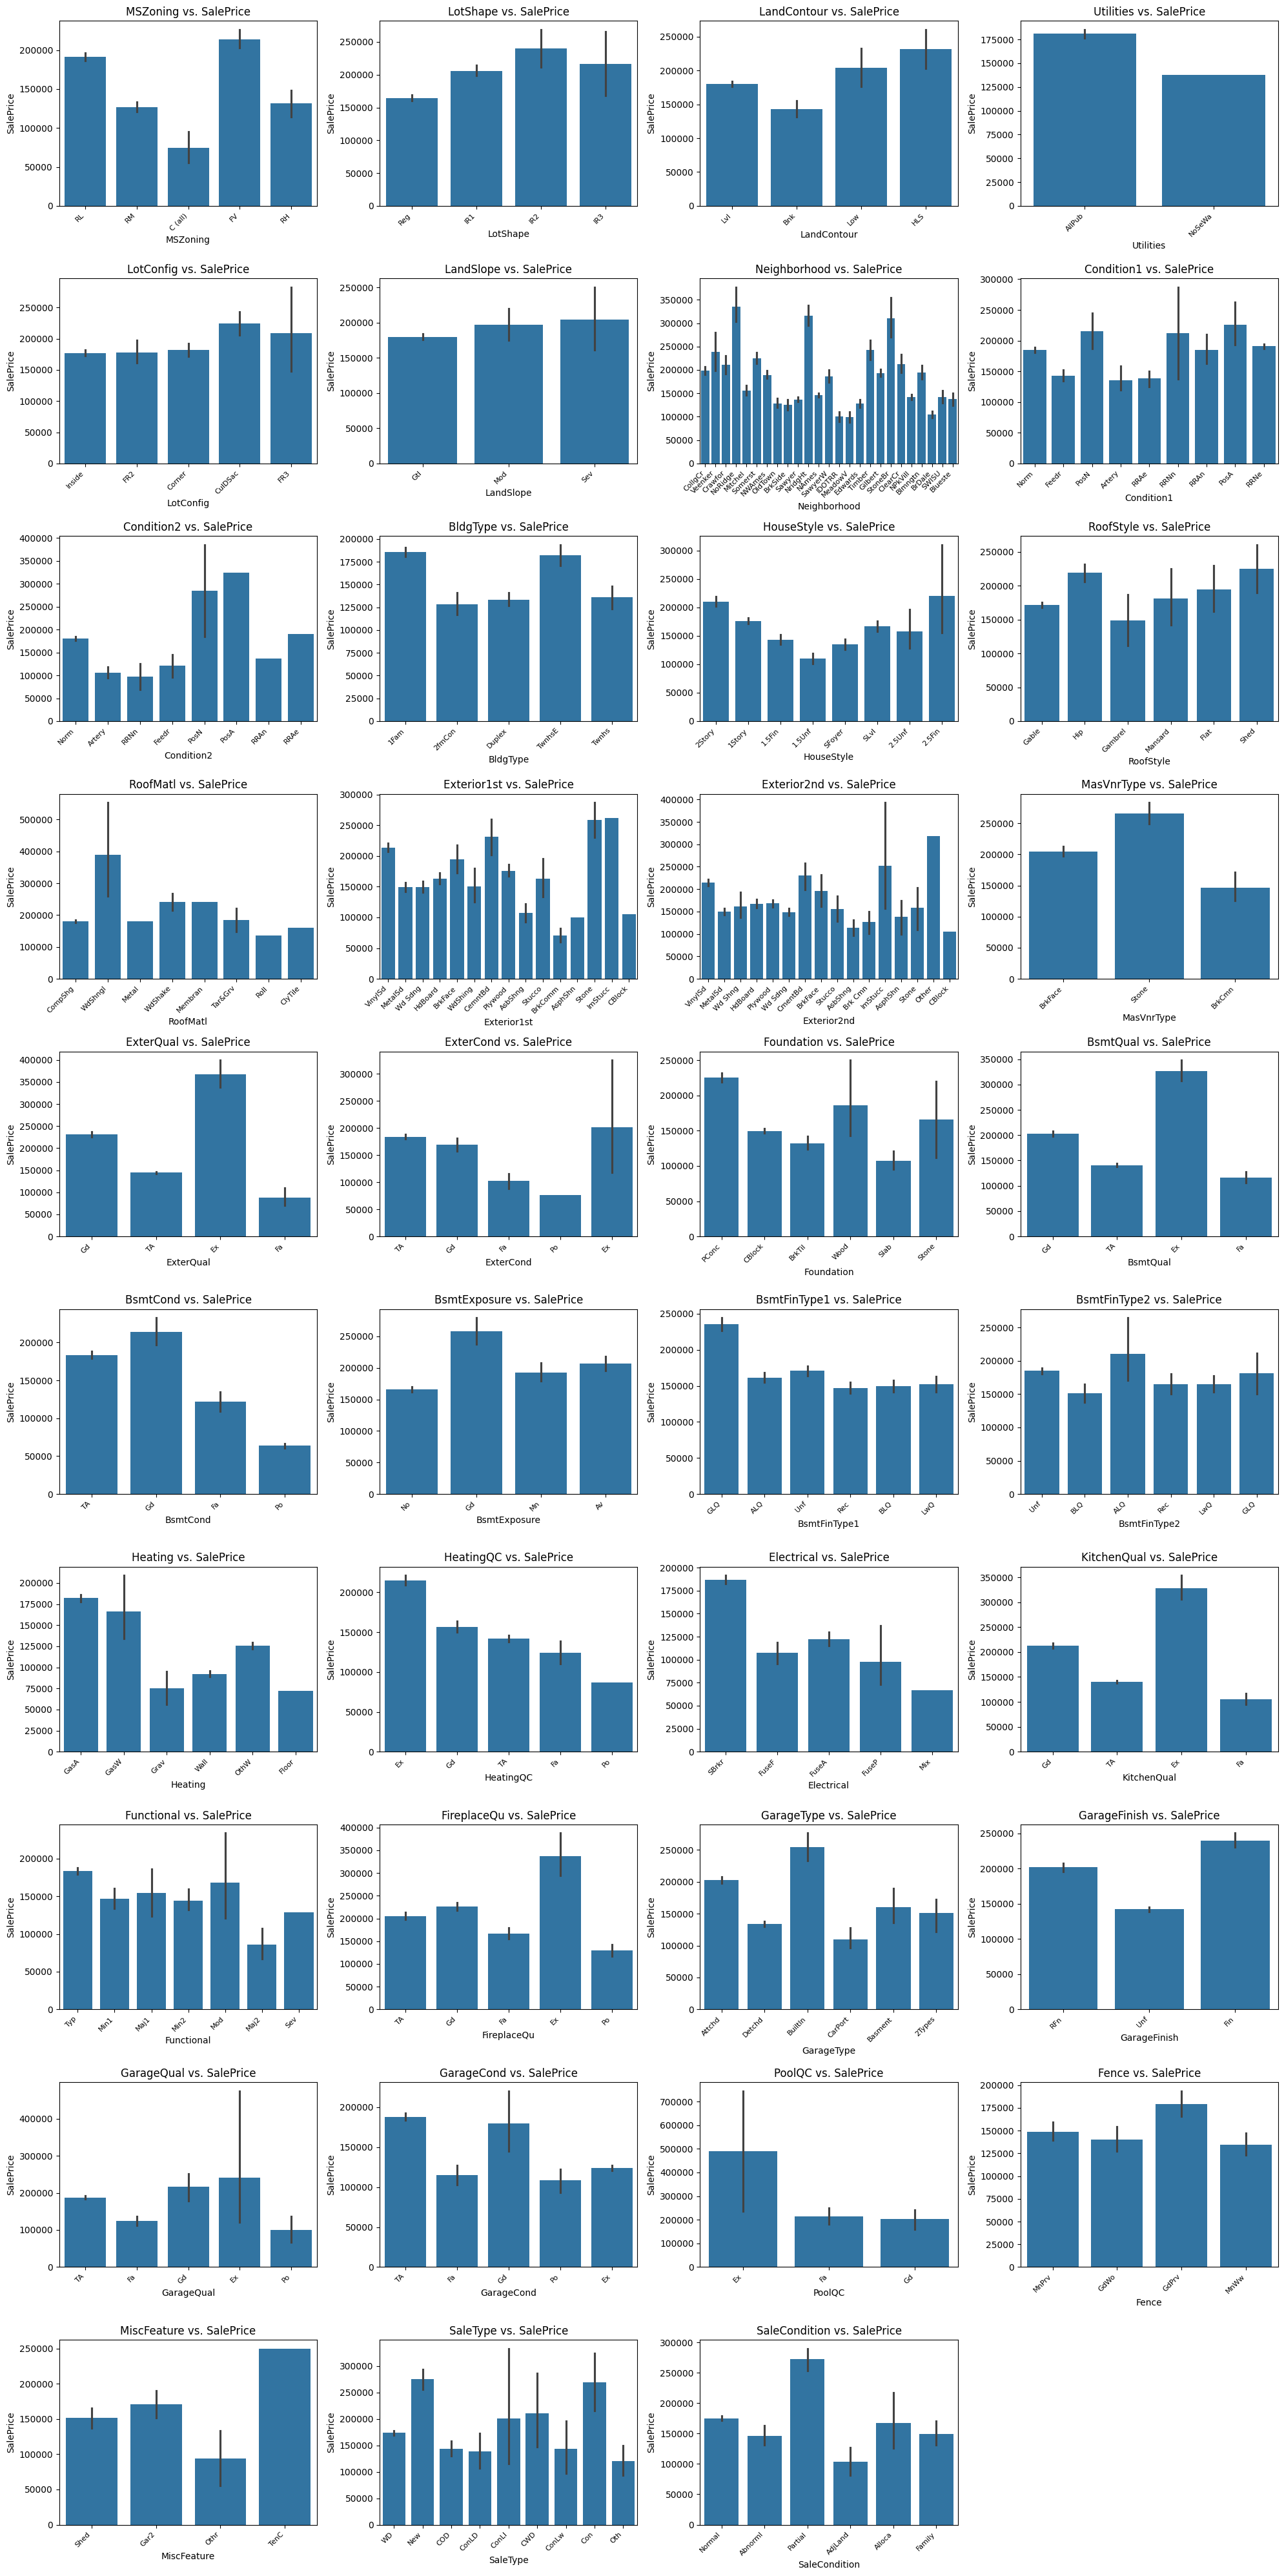

In [18]:
# Extract categorical columns into a DataFrame
cat_cols = data1[[
    'MSZoning', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
    'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
    'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'Heating', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
    'MiscFeature', 'SaleType', 'SaleCondition'
]]

# Set plot size
plt.figure(figsize=(20, 40))

# Loop through each categorical column without enumerate
for i in range(len(cat_cols.columns)):
    col = cat_cols.columns[i]  # Access column name directly
    plt.subplot(10, 4, i + 1)  # 9 rows, 5 columns grid
    sns.barplot(x=col, y='SalePrice', data=data1)
    plt.xticks(rotation=45, ha='right', fontsize=8)  # Rotate x-axis labels if needed
    plt.title(f'{col} vs. SalePrice')

# Adjust layout
plt.tight_layout()
plt.show()

# **INSIGHTS**

1)Top Influential Categorical Features

These features show a strong variation in average SalePrice across categories:

Neighborhood:

-Some neighborhoods like NoRidge, StoneBr, and NridgHt have significantly higher average SalePrice.

-Others like MeadowV, IDOTRR, and BrDale have the lowest.

ExterQual:

-Ex (Excellent) and Gd (Good) exterior quality homes command higher prices.

-Fa and TA homes are priced lower on average.

KitchenQual:

-Ex and Gd kitchens are associated with higher SalePrices.

-Poorer kitchen quality (Fa, TA) reduces house value.

GarageFinish:

-Homes with Fin (Finished) garages have higher SalePrice than Unf or RFn.

BsmtQual:

-Ex and Gd basements lead to higher prices compared to TA and Fa.

MasVnrType:

-Stone veneer homes tend to be more expensive than those with no veneer or BrkCmn.

FireplaceQu:

-Higher fireplace quality like Ex and Gd aligns with higher SalePrices.

PoolQC:

-Houses with excellent pools (Ex) are priced very high, though rare.

GarageQual / GarageCond:

-Higher garage quality and condition lead to noticeable price increases.

SaleCondition:

-Partial sales (new homes) often fetch higher prices.

2) Moderate Impact Features

These show noticeable trends but with less dramatic differences:

HouseStyle:

-2Story and 1.5Fin tend to be more expensive than 1Story.

RoofStyle:

-Hip and Gable styles are priced higher than Flat.

Foundation
PConc foundations result in higher SalePrices.

HeatingQC:

-Excellent (Ex) heating quality gives a boost in value.

GarageType:

-Attchd and BuiltIn types perform better than Detchd.

Fence:

-GdPrv (Good Privacy) fences correlate with higher prices.

3)Low Influence or Sparse Features

Utilities:

-Almost all houses have the same utility rating, so minimal impact.

Condition2, Alley, MiscFeature:

-Sparse data—majority of values fall under one category.

Functional, LandContour, BsmtCond:

-Minor variations in SalePrice; not strong influencers.


In [19]:
# To find out whether the data is continous or discrete
for column in num_col:
    print(f"Value counts for column: {column}")
    print(data1[column].value_counts())
    print("\n")

Value counts for column: MSSubClass
MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64


Value counts for column: LotFrontage
LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
182.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64


Value counts for column: LotArea
LotArea
7200     25
9600     24
6000     17
10800    14
8400     14
         ..
10652     1
12968     1
11924     1
14260     1
9550      1
Name: count, Length: 1073, dtype: int64


Value counts for column: OverallQual
OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64


Value counts for column: OverallCond
OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name:

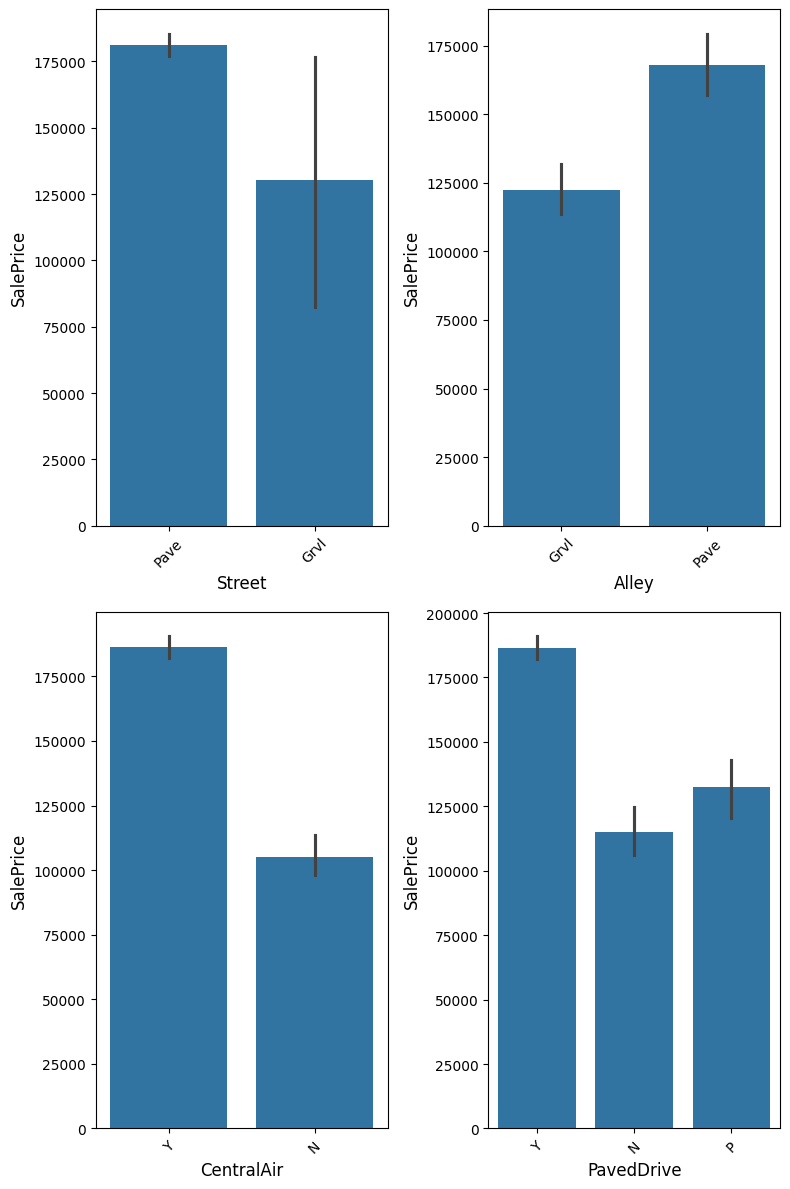

In [20]:
# Creating violin plots for categorical columns vs SalePrice
dis_cat = data1[['Street', 'Alley', 'CentralAir', 'PavedDrive']]

plt.figure(figsize=(8, 12))
plotnumber = 1

for col in dis_cat.columns:
    if plotnumber <= 4:
        plt.subplot(2, 2, plotnumber)
        sns.barplot(x=col, y='SalePrice', data=data1)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('SalePrice', fontsize=12)
        plt.xticks(rotation=45)
        plotnumber += 1

plt.tight_layout()
plt.show()


# **INSIGHTS**

Street Type:
 Houses on paved streets usually sell for a lot more money than houses on gravel streets.

Alley Access:
 If a house has an alley that's paved, it tends to sell for a bit more than if the alley is gravel.

Central Air:
 Houses with central air conditioning sell for much more money than houses without it.

Driveway:
 Houses with a paved driveway sell for the most. A driveway that's only partially paved sells for a bit more than one with no pavement.

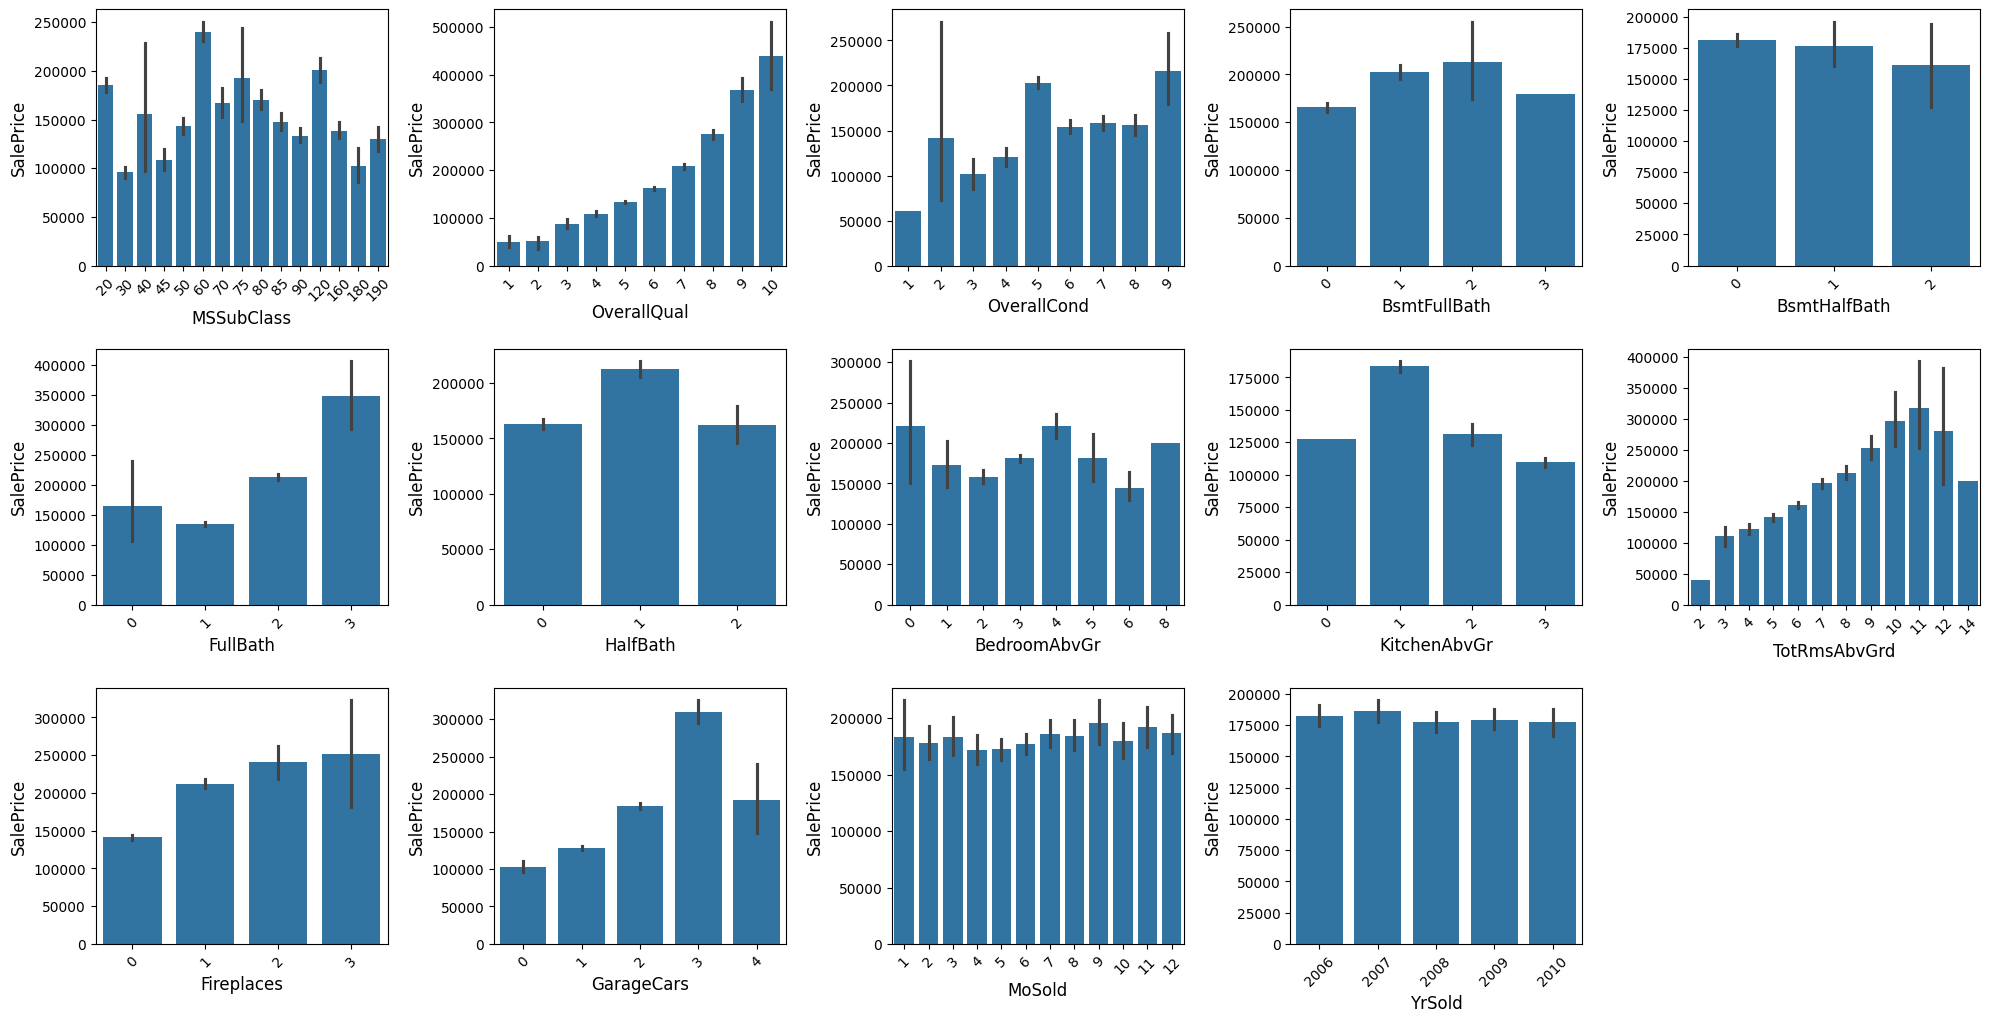

In [21]:
dis_col = data1[['MSSubClass', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath',
                 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
                 'Fireplaces', 'GarageCars', 'MoSold', 'YrSold']]

# Create countplots for each discrete numerical column
plt.figure(figsize=(20, 30))
plotnumber = 1

for col in dis_col.columns:  # Loop over column names
    if plotnumber <= 45:
        plt.subplot(9, 5, plotnumber)
        sns.barplot(data=data1, x=col, y='SalePrice',)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('SalePrice', fontsize=12)
        plt.xticks(rotation=45)
        plotnumber += 1

plt.tight_layout()
plt.show()

# **Insights for Discrete Numerical Features**

1. MSSubClass

 -Some house types (like 60 and 120) sell for more.

 -Different house styles have different price levels.

2. Overall Quality (OverallQual)

 -Better quality homes = higher prices.

 -Homes rated 8–10 are much more expensive.

3. Overall Condition (OverallCond)

 -Condition matters, but not as much as quality.

 -Good condition helps, but doesn’t always mean higher price.

4. Basement Full Bath (BsmtFullBath)

 -More basement bathrooms usually mean higher prices.

 -Homes with 2 full basement baths are the most expensive.

5. Basement Half Bath (BsmtHalfBath)

 -Doesn’t make a big difference in price.

 -Extra half bath in basement isn’t a strong selling point.

6. Full Bathroom (FullBath)

 -More full baths = higher prices.

 -3 full baths get the highest prices.

7. Half Bathroom (HalfBath)

 -1 half bath is popular and gives the highest price.

 -2 half baths don’t increase the value much.

8. Bedrooms (BedroomAbvGr)

 -Price doesn’t change much with number of bedrooms.

 -3 or 4 bedrooms seem most common.

 9. Kitchens (KitchenAbvGr)

 -1 kitchen is best.

 -More than 1 kitchen might lower the price a bit.

10. Total Rooms (TotRmsAbvGrd)

 -More rooms usually = higher price (up to 10 rooms).

 -After 10 rooms, price doesn't go up much more.

11. Fireplaces

 -More fireplaces = higher price.

 -2 or 3 fireplaces add value.

12. Garage Cars (GarageCars)

 -More garage space = higher price.

 -3-car garages have the highest prices.

13. Month Sold (MoSold)

 -Slight price increase in summer months (May to July).

 -No big difference overall.

14. Year Sold (YrSold)

 -Homes sold in 2006–2007 were more expensive.

 -Prices dropped a bit after that (possibly due to market crash).



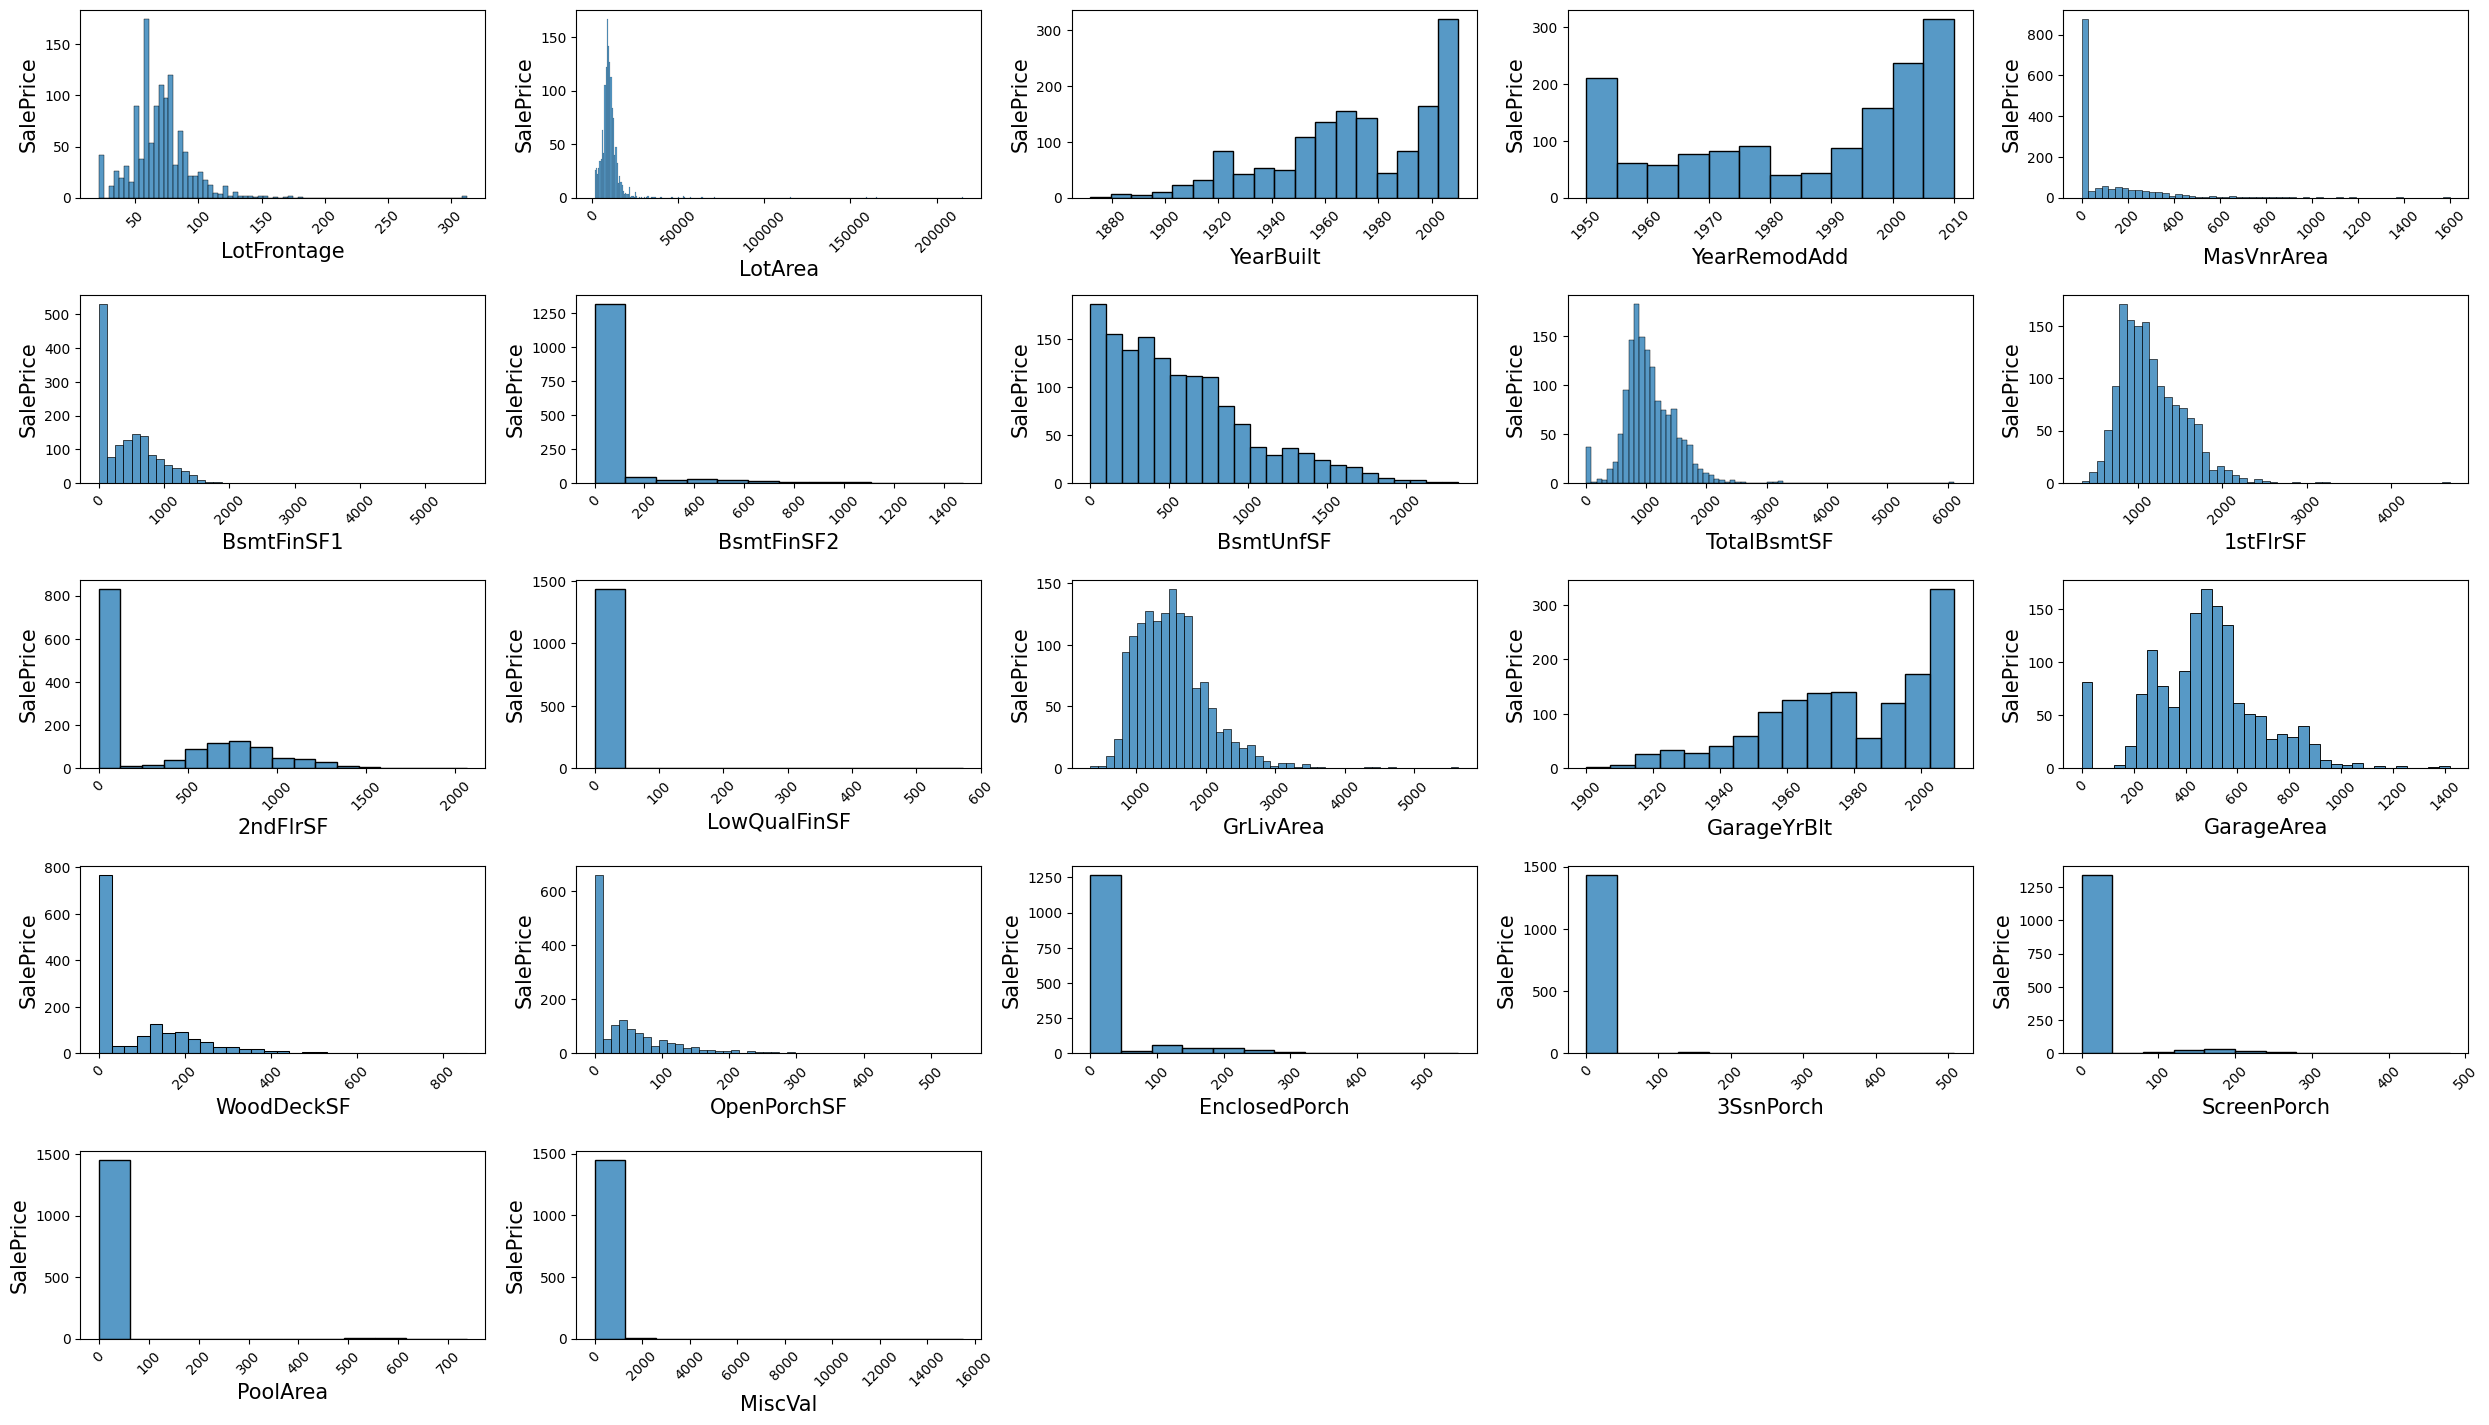

In [22]:
cont_col=data1[['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
                'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF',
                'LowQualFinSF', 'GrLivArea', 'GarageYrBlt','GarageArea', 'WoodDeckSF', 'OpenPorchSF',
                'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea','MiscVal']]

#creating histplot for continuous columns
plt.figure(figsize=(25,25))
plotnumber=1
for i in cont_col:
  if plotnumber<=45:
    plt.subplot(9,5,plotnumber)
    sns.histplot(data=cont_col,x=cont_col[i])
    plt.xlabel(i,fontsize=15)
    plt.ylabel('SalePrice',fontsize=15)
    plt.xticks(rotation=45)
    plotnumber+=1
plt.tight_layout()
plt.show()


# **Insights for Continuous Numerical Features**

1. LotFrontage

 -Slightly right-skewed. Most properties have frontage between 50 and 100 feet.

2. LotArea

 -Heavily right-skewed. Majority of lots are under 20,000 sq ft, with few very large lots as outliers.

3. YearBuilt

 -Strong right skew toward newer properties. Spikes seen around 2000–2010.

4. YearRemodAdd

 -Many houses were remodeled in recent years (2000–2010). Very few before 1950.

5. MasVnrArea

Right-skewed with most values near 0, indicating many homes lack masonry veneer.

6. BsmtFinSF1

 -Right-skewed. Most homes have 0–1000 sq ft of finished basement (type 1).

7. BsmtFinSF2

 -Most homes have 0 sq ft in this category, showing it's rarely used.

8. BsmtUnfSF

 -Spread across 0–1500 sq ft. Many homes have some unfinished basement area.

9. TotalBsmtSF

 -Bell-shaped distribution centered around 1000 sq ft, most homes have basement areas.

10. 1stFlrSF

 -Normal-like distribution centered around 1000–1500 sq ft, common first floor size.

11. 2ndFlrSF

 -Most homes either have no second floor or between 400–1000 sq ft upstairs.

12. LowQualFinSF

Nearly all values are zero—low quality finished areas are rare.

13. GrLivArea

 -Slightly right-skewed. Most homes have 1000–2500 sq ft of above-ground living space.

14. GarageYrBlt

 -Mirrors YearBuilt distribution—most garages built post-1950 with spikes in recent decades.

15. GarageArea

 -Most garage sizes range between 400–600 sq ft, aligning with 1–2 car capacity.

16. WoodDeckSF

 -Right-skewed with majority having no deck or small ones below 300 sq ft.

17. OpenPorchSF

 -Skewed distribution; many homes have no open porch.

18. EnclosedPorch

 -Most homes don’t have enclosed porches.

19. 3SsnPorch

 -Almost all values are zero. Very few homes have a 3-season porch.

20. ScreenPorch

 -Same trend—very few homes include a screened porch.

21. PoolArea

 -Nearly all homes have no pool area. Pool homes are outliers.

22. MiscVal

 -Most values are 0. Indicates very few homes have miscellaneous additions like sheds, etc.

# **Data Preprocessing**

In [23]:

pd.set_option('display.max_rows',None)
data1.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0
LotConfig,0


In [24]:
data1.isnull().sum()/len(data1)*100

,0
MSSubClass,0.000000
MSZoning,0.000000
LotFrontage,17.739726
LotArea,0.000000
Street,0.000000
Alley,93.767123
LotShape,0.000000
LandContour,0.000000
Utilities,0.000000
LotConfig,0.000000


In [25]:
data1.drop(columns=['Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)# dropping columns which has missing values greater than 80%

In [26]:
data1.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

<Axes: xlabel='LotFrontage', ylabel='Count'>

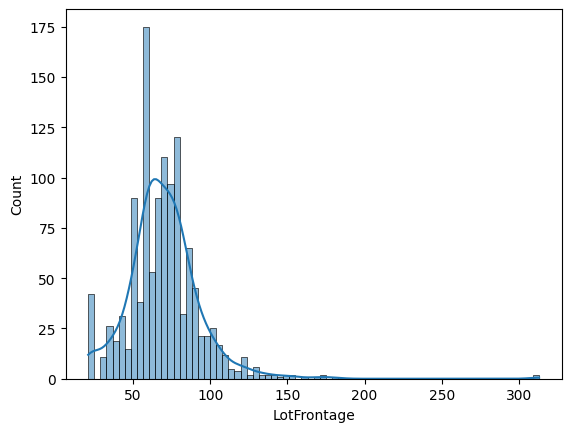

In [27]:
#Handling missing values
# check distribution ofLotFrontage
sns.histplot(data=data1,x=data1.LotFrontage,kde=True)

In [28]:
# check median for LotFrontage column
data1.LotFrontage.median()

69.0

In [29]:
data1.loc[data1.LotFrontage.isnull()==True,'LotFrontage']=data1.LotFrontage.median()

1980.0


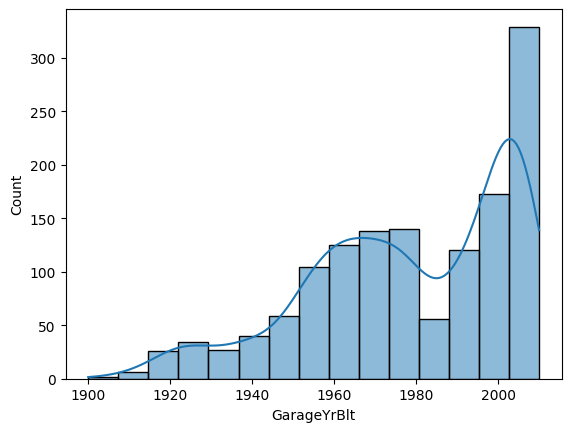

In [30]:
#Handling missing values for numerical
# check distribution GarageYrBlt
sns.histplot(data=data1,x=data1.GarageYrBlt,kde=True)


# check median for GarageYrBlt column
data1.GarageYrBlt.median()
print(data1.GarageYrBlt.median())


In [31]:
data1.loc[data1.GarageYrBlt.isnull()==True,'GarageYrBlt']=data1.GarageYrBlt.median()

In [32]:
#Handling missing values for categorical columns
# List of categorical columns to handle
categorical_cols = ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
                    'GarageQual', 'GarageCond']

# Replace missing values with mode and print the mode
for col in categorical_cols:
    mode = data1[col].mode()[0]
    missing = data1[col].isnull().sum()
    data1.loc[data1[col].isnull(), col] = mode
    print(f"{col}: filled {missing} missing values using mode = '{mode}'")


MasVnrType: filled 872 missing values using mode = 'BrkFace'
BsmtQual: filled 37 missing values using mode = 'TA'
BsmtCond: filled 37 missing values using mode = 'TA'
BsmtExposure: filled 38 missing values using mode = 'No'
BsmtFinType1: filled 37 missing values using mode = 'Unf'
BsmtFinType2: filled 38 missing values using mode = 'Unf'
FireplaceQu: filled 690 missing values using mode = 'Gd'
GarageType: filled 81 missing values using mode = 'Attchd'
GarageFinish: filled 81 missing values using mode = 'Unf'
GarageQual: filled 81 missing values using mode = 'TA'
GarageCond: filled 81 missing values using mode = 'TA'


In [33]:
data1.isnull().sum()[data1.isnull().sum() > 0]



,0
MasVnrArea,8
Electrical,1


In [34]:
data1['MasVnrArea'].fillna(0, inplace=True)


# **Check For Outliers**

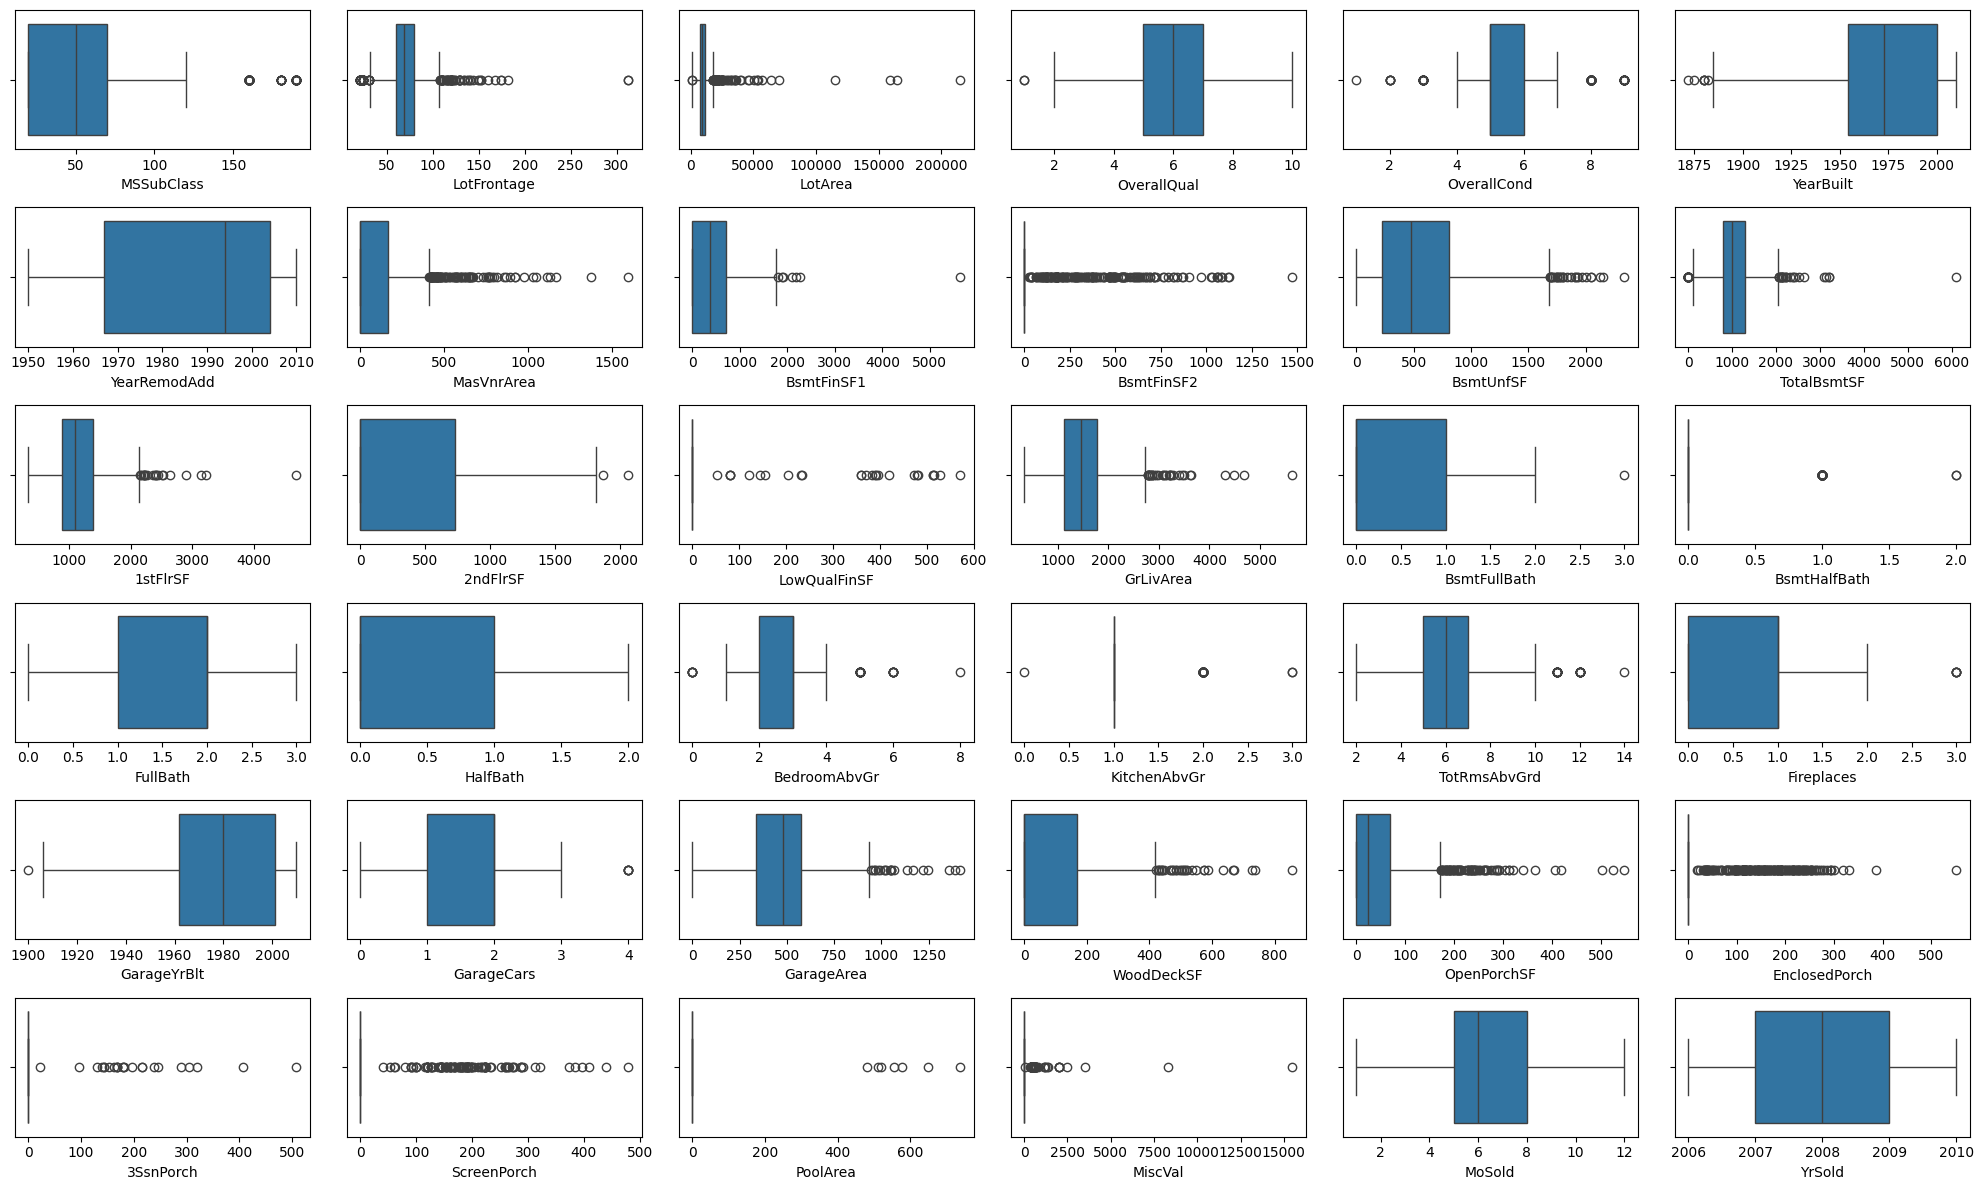

In [35]:

# List of numerical columns
num_cols = ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
           'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
           'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
           'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
           'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
           'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
           'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
           'MoSold', 'YrSold']

# Plotting boxplots for all numerical columns
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 6, i)  # 6x6 grid of subplots
    sns.boxplot(x=data1[col])  # Boxplot for each column


plt.tight_layout()  # Adjust layout for better spacing
plt.show()


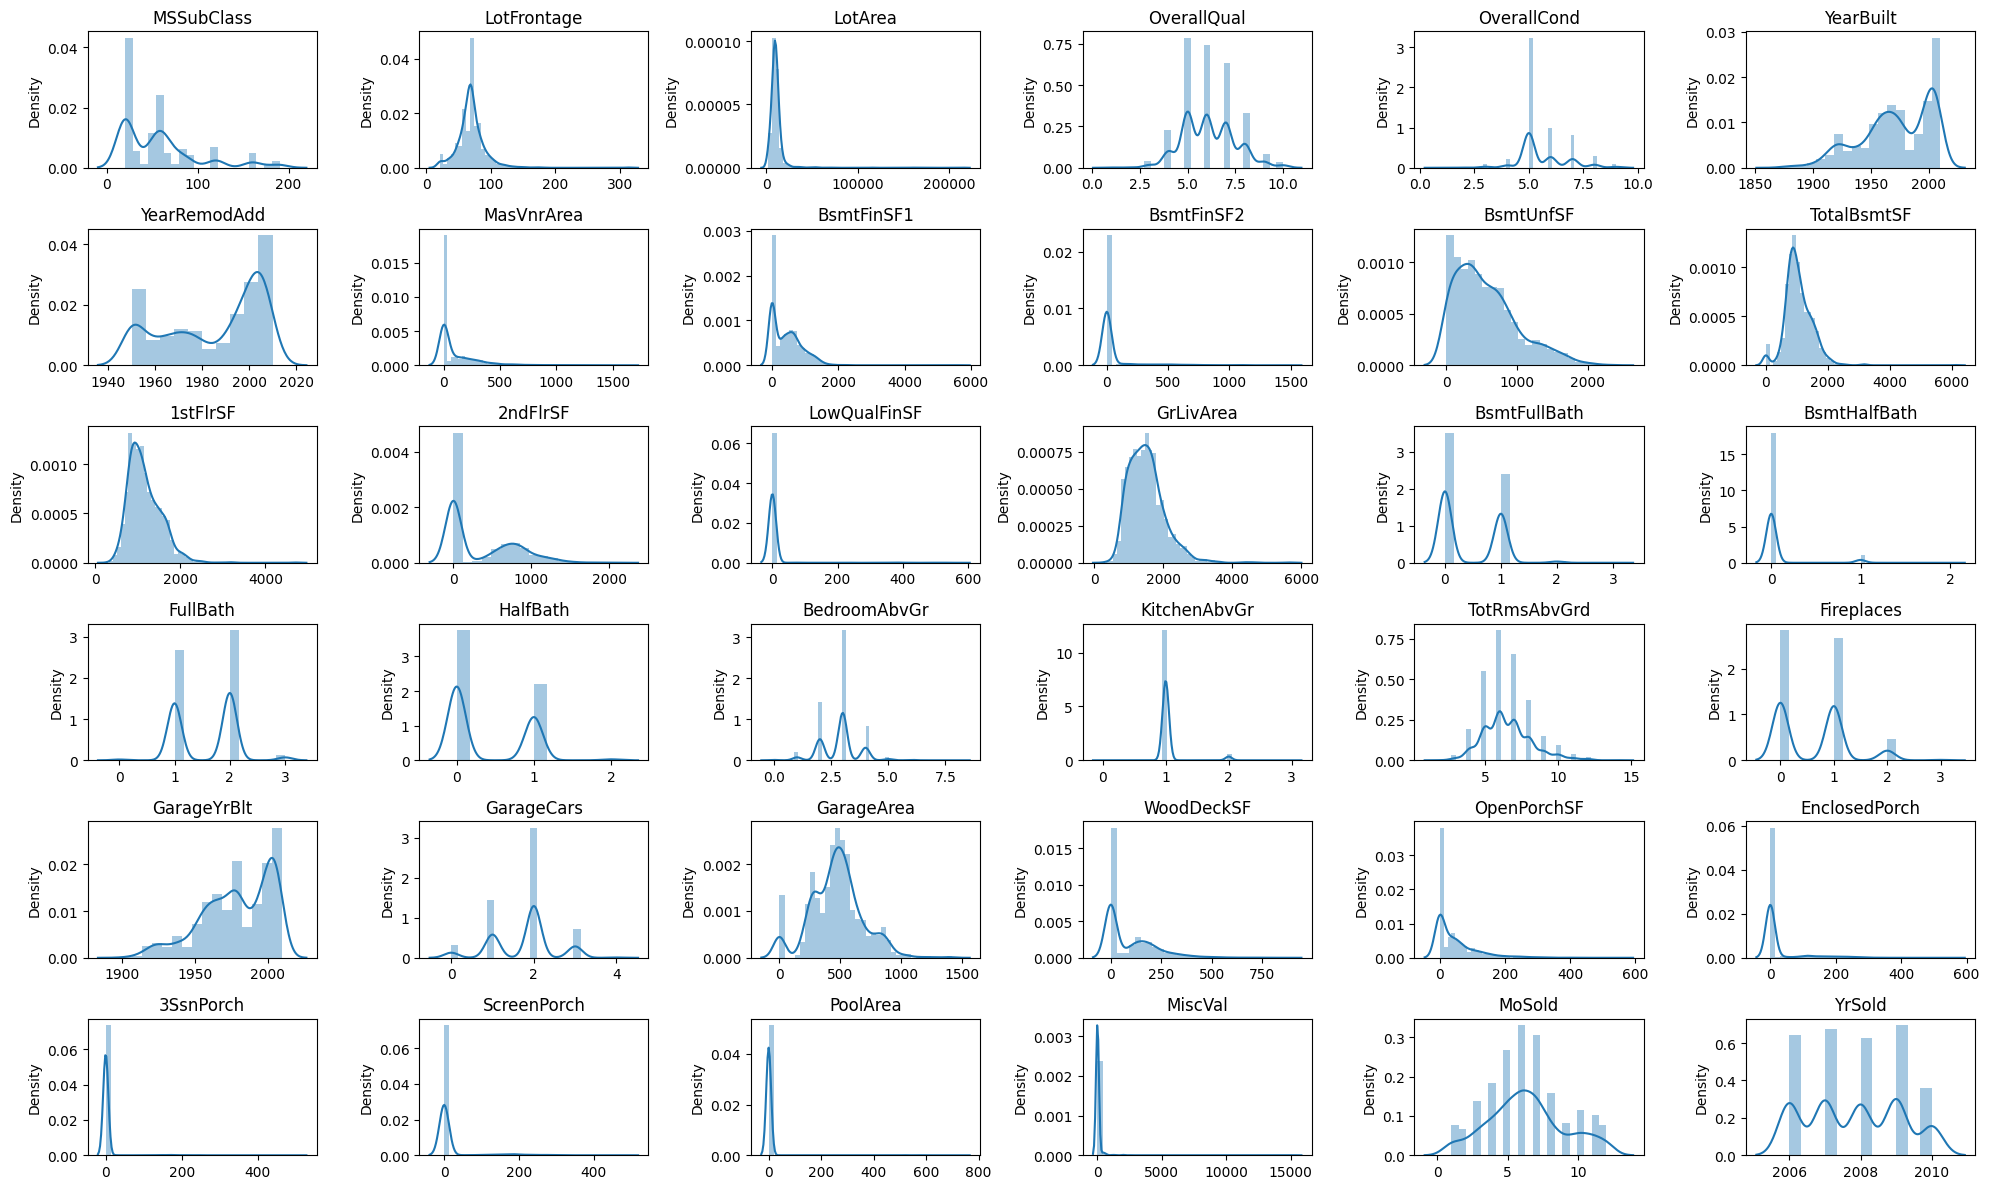

In [36]:
#creating distplot for numerical columns to know which rule to use whether IQR or 3 sigma
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 6, i)  # 6x6 grid of subplots
    sns.distplot(x=data1[col])  # distplot for each column
    plt.title(col)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


In [37]:
# First quantile (Q1)
Q1 = data1[num_cols].quantile(0.25)  # Use num_col to select numerical columns
# Third quantile (Q3)
Q3 = data1[num_cols].quantile(0.75)  # Use num_col to select numerical columns
# IQR value
IQR = Q3 - Q1
# Getting the limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
# Sum of outliers
# Use num_col to select numerical columns for outlier calculation
outliers_count = ((data1[num_cols] > upper_limit) | (data1[num_cols] < lower_limit)).sum()
# Percentage of outliers
outliers_percentage = (outliers_count / len(data1)) * 100
print('Sum of Outliers: ', outliers_count)
print('Percentage of Outliers:', outliers_percentage)

filtered_columns = outliers_percentage[(outliers_percentage > 0) & (outliers_percentage < 5)]

if filtered_columns.any():
    print("Columns that need to be handled:", filtered_columns)

Sum of Outliers:  MSSubClass       103
LotFrontage      106
LotArea           69
OverallQual        2
OverallCond      125
YearBuilt          7
YearRemodAdd       0
MasVnrArea        98
BsmtFinSF1         7
BsmtFinSF2       167
BsmtUnfSF         29
TotalBsmtSF       61
1stFlrSF          20
2ndFlrSF           2
LowQualFinSF      26
GrLivArea         31
BsmtFullBath       1
BsmtHalfBath      82
FullBath           0
HalfBath           0
BedroomAbvGr      35
KitchenAbvGr      68
TotRmsAbvGrd      30
Fireplaces         5
GarageYrBlt        1
GarageCars         5
GarageArea        21
WoodDeckSF        32
OpenPorchSF       77
EnclosedPorch    208
3SsnPorch         24
ScreenPorch      116
PoolArea           7
MiscVal           52
MoSold             0
YrSold             0
dtype: int64
Percentage of Outliers: MSSubClass        7.054795
LotFrontage       7.260274
LotArea           4.726027
OverallQual       0.136986
OverallCond       8.561644
YearBuilt         0.479452
YearRemodAdd      0.000000


### By analysing box plot above,  Not handled outliers for below columns

OverallQual,PoolArea,MiscVal,  3SsnPorch,GarageYrBlt,
LowQualFinSF,
BedroomAbvGr,
KitchenAbvGr,
TotRmsAbvGrd,
2ndFlrSF,
Fireplaces.

It has low frequencies and not suitable for handling outliers.

Columns are realistic and valid, not data errors.

## **Columns that need to handle outliers are below**

LotFrontage,
LotArea,
OverallCond,
YearBuilt,
MasVnrArea,
BsmtFinSF1,
BsmtUnfSF,
TotalBsmtSF,
1stFlrSF,
GrLivArea,
GarageYrBlt,
GarageArea,
WoodDeckSF,
OpenPorchSF



In [38]:
outlier=['LotFrontage','LotArea','OverallCond','YearBuilt',
         'MasVnrArea','BsmtFinSF1','BsmtUnfSF','TotalBsmtSF','1stFlrSF',
         'GrLivArea','GarageYrBlt','GarageArea','WoodDeckSF','OpenPorchSF']

for col in outlier:







    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    lower_count = len(data1[data1[col] < lower_limit])
    upper_count = len(data1[data1[col] > upper_limit])
    total = len(data1)

    lower_percent = lower_count / total * 100
    upper_percent = upper_count / total * 100

    print(f"{col}:")
    print(f"  Lower limit: {lower_limit}")
    print(f"  Upper limit: {upper_limit}")
    print(f"  Lower outliers: {lower_count} ({lower_percent:.2f}%)")
    print(f"  Upper outliers: {upper_count} ({upper_percent:.2f}%)\n")


    # Replace outliers with the median value
    column_median = data1[col].median()
    data1.loc[data1[col] < lower_limit, col] = column_median
    data1.loc[data1[col] > upper_limit, col] = column_median


LotFrontage:
  Lower limit: 31.5
  Upper limit: 107.5
  Lower outliers: 48 (3.29%)
  Upper outliers: 58 (3.97%)

LotArea:
  Lower limit: 1481.5
  Upper limit: 17673.5
  Lower outliers: 2 (0.14%)
  Upper outliers: 67 (4.59%)

OverallCond:
  Lower limit: 3.5
  Upper limit: 7.5
  Lower outliers: 31 (2.12%)
  Upper outliers: 94 (6.44%)

YearBuilt:
  Lower limit: 1885.0
  Upper limit: 2069.0
  Lower outliers: 7 (0.48%)
  Upper outliers: 0 (0.00%)

MasVnrArea:
  Lower limit: -246.375
  Upper limit: 410.625
  Lower outliers: 0 (0.00%)
  Upper outliers: 98 (6.71%)

BsmtFinSF1:
  Lower limit: -1068.375
  Upper limit: 1780.625
  Lower outliers: 0 (0.00%)
  Upper outliers: 7 (0.48%)

BsmtUnfSF:
  Lower limit: -654.5
  Upper limit: 1685.5
  Lower outliers: 0 (0.00%)
  Upper outliers: 29 (1.99%)

TotalBsmtSF:
  Lower limit: 42.0
  Upper limit: 2052.0
  Lower outliers: 37 (2.53%)
  Upper outliers: 24 (1.64%)

1stFlrSF:
  Lower limit: 118.125
  Upper limit: 2155.125
  Lower outliers: 0 (0.00%)
  Uppe

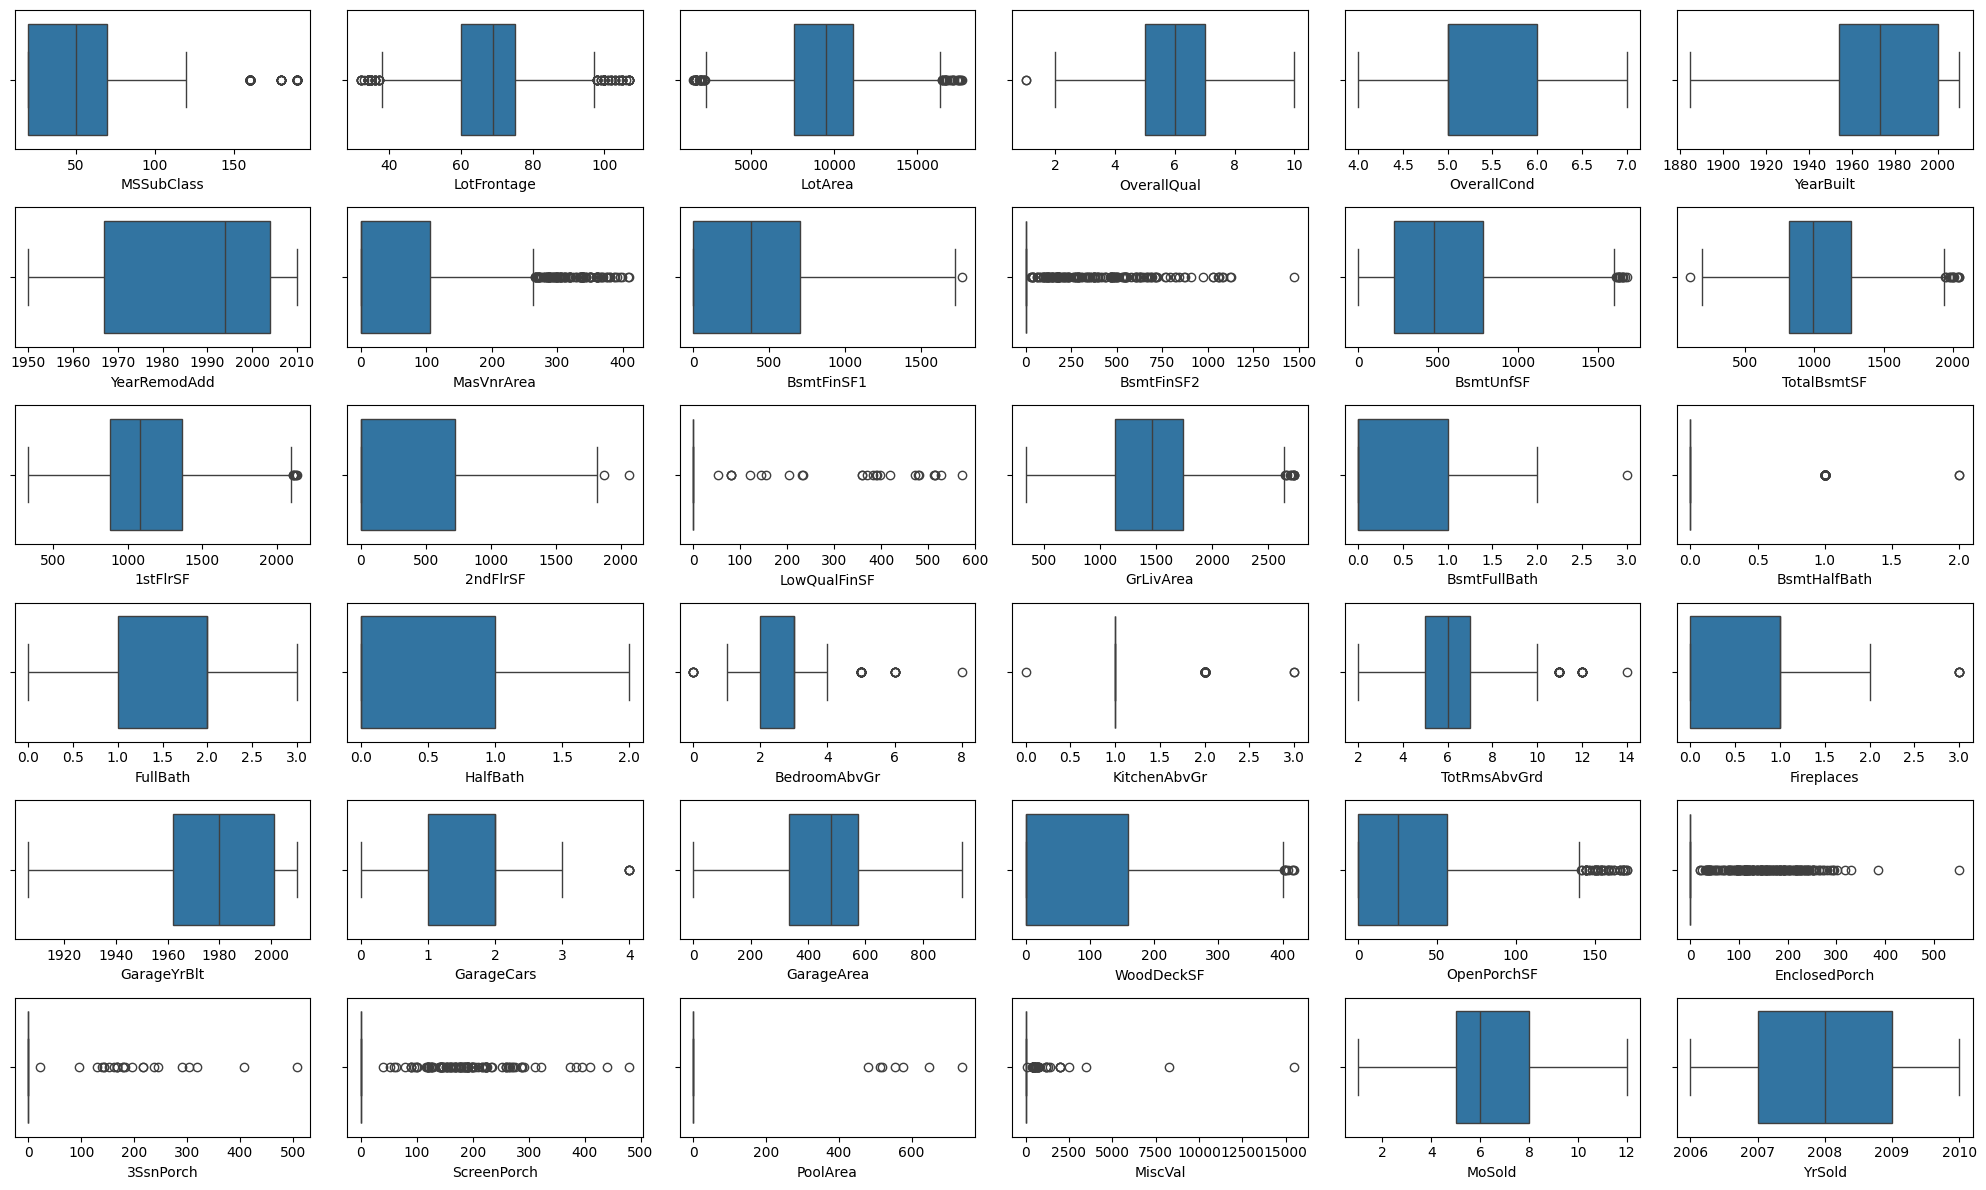

In [39]:

# List of numerical columns
num_cols = ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
           'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
           'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
           'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
           'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
           'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
           'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
           'MoSold', 'YrSold']

# Plotting boxplots for all numerical columns
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 6, i)  # 6x6 grid of subplots
    sns.boxplot(x=data1[col])  # Boxplot for each column


plt.tight_layout()  # Adjust layout for better spacing
plt.show()


#Handling outliers
Q1=data1['LotFrontage'].quantile(0.25)
print("lower quartile",Q1)
Q3=data1['LotFrontage'].quantile(0.75)
print('upper quartile',Q3)



IQR=Q3-Q1
print('IQR',IQR)



lower_limit=Q1-1.5*IQR
print('lower_limit is ',lower_limit)
upper_limit=Q3+1.5*IQR
print('upper_limit is ',upper_limit)





print(len(data1.loc[data1['LotFrontage']>upper_limit])/len(data1))

print(len(data1.loc[data1['LotFrontage']<lower_limit])/len(data1))


data1.loc[data1['LotFrontage']>upper_limit,'LotFrontage']=data1['LotFrontage'].median()

data1.loc[data1['LotFrontage']<lower_limit,'LotFrontage']=data1['LotFrontage'].median()

sns.boxplot(x=data1['LotFrontage'])




# Converting Categorical columns to Numerical

In [40]:
# using label encoder to convert the categorical data to numerical data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data1['MSZoning'] = le.fit_transform(data1['MSZoning'])
data1['Street'] = le.fit_transform(data1['Street'])
data1['LotConfig'] = le.fit_transform(data1['LotConfig'])
data1['LandContour'] = le.fit_transform(data1['LandContour'])
data1['LandSlope'] = le.fit_transform(data1['LandSlope'])
data1['Utilities'] = le.fit_transform(data1['Utilities'])
data1['Condition1'] = le.fit_transform(data1['Condition1'])
data1['Condition2'] = le.fit_transform(data1['Condition2'])
data1['BldgType'] = le.fit_transform(data1['BldgType'])
data1['HouseStyle'] = le.fit_transform(data1['HouseStyle'])
data1['RoofStyle'] = le.fit_transform(data1['RoofStyle'])
data1['RoofMatl'] = le.fit_transform(data1['RoofMatl'])
data1['MasVnrType'] = le.fit_transform(data1['MasVnrType'])
data1['CentralAir'] = le.fit_transform(data1['CentralAir'])
data1['Electrical'] = le.fit_transform(data1['Electrical'])
data1['GarageType'] = le.fit_transform(data1['GarageType'])
data1['SaleType'] = le.fit_transform(data1['SaleType'])
data1['SaleCondition'] = le.fit_transform(data1['SaleCondition'])
data1['Foundation'] = le.fit_transform(data1['Foundation'])
data1['Heating'] = le.fit_transform(data1['Heating'])
data1['Functional'] = le.fit_transform(data1['Functional'])


In [41]:
# using mapping encoding  to convert the categorical data to numerical data

ordinal_mappings = {
    'ExterQual': {'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'ExterCond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual': {'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'BsmtCond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4},
    'BsmtExposure': {'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'HeatingQC': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'FireplaceQu': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageFinish': {'Unf': 1, 'RFn': 2, 'Fin': 3},
    'GarageQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'PavedDrive': {'N': 1, 'P': 2, 'Y': 3}}

# Apply mapping encoding
for col, mapping in ordinal_mappings.items():
    data1[col] = data1[col].map(mapping)


In [42]:
data1.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450.0,1,Reg,3,0,4,0,CollgCr,2,2,0,5,7,5,2003,2003,1,1,VinylSd,VinylSd,1,196.0,3,3,2,3,3,1,6,706.0,1,0,150.0,856.0,1,5,1,4,856,854,0,1710,1,0,2,1,3,1,3,8,6,0,4,1,2003.0,2,2,548,3,3,3,0,61,0,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600.0,1,Reg,3,0,2,0,Veenker,1,2,0,2,6,5,1976,1976,1,1,MetalSd,MetalSd,1,0.0,2,3,1,3,3,4,5,978.0,1,0,284.0,1262.0,1,5,1,4,1262,0,0,1262,0,1,2,0,3,1,2,6,6,1,3,1,1976.0,2,2,460,3,3,3,298,0,0,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250.0,1,IR1,3,0,4,0,CollgCr,2,2,0,5,7,5,2001,2002,1,1,VinylSd,VinylSd,1,162.0,3,3,2,3,3,2,6,486.0,1,0,434.0,920.0,1,5,1,4,920,866,0,1786,1,0,2,1,3,1,3,6,6,1,3,1,2001.0,2,2,608,3,3,3,0,42,0,0,0,0,0,9,2008,8,4,223500
3,70,3,60.0,9550.0,1,IR1,3,0,0,0,Crawfor,2,2,0,5,7,5,1915,1970,1,1,Wd Sdng,Wd Shng,1,0.0,2,3,0,2,4,1,5,216.0,1,0,540.0,756.0,1,4,1,4,961,756,0,1717,1,0,1,0,3,1,3,7,6,1,4,5,1998.0,1,3,642,3,3,3,0,35,272,0,0,0,0,2,2006,8,0,140000
4,60,3,84.0,14260.0,1,IR1,3,0,2,0,NoRidge,2,2,0,5,8,5,2000,2000,1,1,VinylSd,VinylSd,1,350.0,3,3,2,3,3,3,6,655.0,1,0,490.0,1145.0,1,5,1,4,1145,1053,0,2198,1,0,2,1,4,1,3,9,6,1,3,1,2000.0,2,3,836,3,3,3,192,84,0,0,0,0,0,12,2008,8,4,250000


In [43]:
# using Frequency encoding  to convert the categorical data to numerical data

# Frequency encoding for 'Exterior1st'
ext1_freq = data1['Exterior1st'].value_counts(normalize=True)
data1['Exterior1st'] = data1['Exterior1st'].map(ext1_freq)

# Frequency encoding for 'Exterior2nd'
ext2_freq = data1['Exterior2nd'].value_counts(normalize=True)
data1['Exterior2nd'] = data1['Exterior2nd'].map(ext2_freq)

# Frequency encoding for 'Neighborhood'
neigh_freq = data1['Neighborhood'].value_counts(normalize=True)
data1['Neighborhood'] = data1['Neighborhood'].map(neigh_freq)

# Frequency encoding for 'LotShape'
lotshape_freq = data1['LotShape'].value_counts(normalize=True)
data1['LotShape'] = data1['LotShape'].map(lotshape_freq)


In [44]:
data1.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450.0,1,0.633562,3,0,4,0,0.102740,2,2,0,5,7,5,2003,2003,1,1,0.352740,0.345205,1,196.0,3,3,2,3,3,1,6,706.0,1,0,150.0,856.0,1,5,1,4,856,854,0,1710,1,0,2,1,3,1,3,8,6,0,4,1,2003.0,2,2,548,3,3,3,0,61,0,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600.0,1,0.633562,3,0,2,0,0.007534,1,2,0,2,6,5,1976,1976,1,1,0.150685,0.146575,1,0.0,2,3,1,3,3,4,5,978.0,1,0,284.0,1262.0,1,5,1,4,1262,0,0,1262,0,1,2,0,3,1,2,6,6,1,3,1,1976.0,2,2,460,3,3,3,298,0,0,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250.0,1,0.331507,3,0,4,0,0.102740,2,2,0,5,7,5,2001,2002,1,1,0.352740,0.345205,1,162.0,3,3,2,3,3,2,6,486.0,1,0,434.0,920.0,1,5,1,4,920,866,0,1786,1,0,2,1,3,1,3,6,6,1,3,1,2001.0,2,2,608,3,3,3,0,42,0,0,0,0,0,9,2008,8,4,223500


# **Scaling**

In [45]:
from sklearn.preprocessing import StandardScaler

# Columns you don't want to scale (frequency-encoded + target)
skip_cols = ['LotShape', 'Neighborhood', 'Exterior1st', 'Exterior2nd', 'SalePrice']

# Select all other columns to scale
scale_cols = [col for col in data1.columns if col not in skip_cols]

# Scale those columns
scaler = StandardScaler()
data1[scale_cols] = scaler.fit_transform(data1[scale_cols])
data1.head(4)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.073375,-0.045532,-0.274093,-0.266799,0.064238,0.633562,0.314667,-0.02618,0.604670,-0.225716,0.102740,-0.036289,-0.03174,-0.411691,1.026689,0.651479,-0.534267,1.060436,0.878668,-0.491516,-0.125797,0.352740,0.345205,-0.255234,1.290955,1.052302,-0.238112,0.835599,0.641645,-0.038577,-0.631676,1.173351,0.644729,-0.314282,-0.288653,-0.971954,-0.589594,-0.123046,0.891179,0.263813,0.301599,-0.835181,1.161852,-0.120242,0.524793,1.107810,-0.241061,0.789741,1.227585,0.163779,-0.211454,0.735994,0.912210,0.255978,-0.951226,0.471313,-0.686776,1.019068,0.281887,0.311725,0.421310,0.096397,0.105926,0.289745,-0.775711,0.604457,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,0.138777,0.313867,0.208502,208500
1,-0.872563,-0.045532,0.809612,0.101854,0.064238,0.633562,0.314667,-0.02618,-0.628316,-0.225716,0.007534,-1.188074,-0.03174,-0.411691,-0.543457,-0.071836,-0.534267,0.145062,-0.429577,-0.491516,-0.125797,0.150685,0.146575,-0.255234,-0.595110,-0.689604,-0.238112,-0.549162,0.641645,-0.038577,2.256363,0.690246,1.287800,-0.314282,-0.288653,-0.637815,0.602011,-0.123046,0.891179,0.263813,0.301599,0.348826,-0.795163,-0.120242,-0.482008,-0.819964,3.948809,0.789741,-0.761621,0.163779,-0.211454,-0.771091,-0.318683,0.255978,0.600495,-1.186799,-0.686776,-0.110619,0.281887,0.311725,-0.020480,0.096397,0.105926,0.289745,2.022812,-0.811305,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.489110,-0.614439,0.313867,0.208502,181500
2,0.073375,-0.045532,-0.057352,0.630791,0.064238,0.331507,0.314667,-0.02618,0.604670,-0.225716,0.102740,-0.036289,-0.03174,-0.411691,1.026689,0.651479,-0.534267,0.992630,0.830215,-0.491516,-0.125797,0.352740,0.345205,-0.255234,0.963781,1.052302,-0.238112,0.835599,0.641645,-0.038577,0.331004,1.173351,0.124597,-0.314282,-0.288653,-0.263779,-0.401755,-0.123046,0.891179,0.263813,0.301599,-0.648539,1.189351,-0.120242,0.695590,1.107810,-0.241061,0.789741,1.227585,0.163779,-0.211454,0.735994,-0.318683,0.255978,0.600495,-1.186799,-0.686776,0.935387,0.281887,0.311725,0.722530,0.096397,0.105926,0.289745,-0.775711,0.163482,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,0.138777,0.313867,0.208502,223500
3,0.309859,-0.045532,-0.635329,0.085825,0.064238,0.331507,0.314667,-0.02618,-1.861302,-0.225716,0.034932,-0.036289,-0.03174,-0.411691,1.026689,0.651479,-0.534267,-1.923005,-0.720298,-0.491516,-0.125797,0.141096,0.026027,-0.255234,-0.595110,-0.689604,-0.238112,-1.933923,-0.833633,3.481550,-0.631676,0.690246,-0.513745,-0.314282,-0.288653,0.000541,-0.883093,-0.123046,-0.151386,0.263813,0.301599,-0.528972,0.937276,-0.120242,0.540524,1.107810,-0.241061,-1.026041,-0.761621,0.163779,-0.211454,0.735994,0.296763,0.255978,0.600495,0.471313,1.586905,0.809867,-0.950313,1.650307,0.893222,0.096397,0.105926,0.289745,-0.775711,0.001017,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,-1.367655,0.313867,-3.426284,140000


# **Feature Engineering**

In [46]:
plt.figure(figsize=(200,200))
sns.heatmap(data1.drop('SalePrice', axis=1).corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})


Output hidden; open in https://colab.research.google.com to view.

In [47]:


# Compute the correlation matrix
corr_matrix = data1.corr(numeric_only=True)

# Absolute correlation matrix (drop self-correlation)
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations (1.0)
corr_pairs = corr_pairs.drop_duplicates().sort_values(ascending=False)

# Set threshold
threshold = 0.8
high_corr = corr_pairs[corr_pairs > threshold]

# Show results
print("🔍 Highly Correlated Feature Pairs (|r| > 0.8):\n")
print(high_corr)


🔍 Highly Correlated Feature Pairs (|r| > 0.8):

Exterior1st   Exterior2nd    0.947892
GarageCars    GarageArea     0.871197
TotalBsmtSF   1stFlrSF       0.825324
BsmtFinType2  BsmtFinSF2     0.803070
dtype: float64


In [48]:
# Drop the selected columns

data1.drop(columns=['Exterior2nd', 'GarageArea', 'TotalBsmtSF', 'BsmtFinType2'], axis=1, inplace=True)
data1.columns


Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch'

# Model Creation

In [49]:
x=data1.drop('SalePrice', axis=1)
y=data1['SalePrice']

In [50]:
# Split data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [51]:
x_train.shape

(1168, 71)

In [52]:
x_test.shape

(292, 71)

In [53]:
y_train.shape

(1168,)

In [54]:
y_test.shape

(292,)

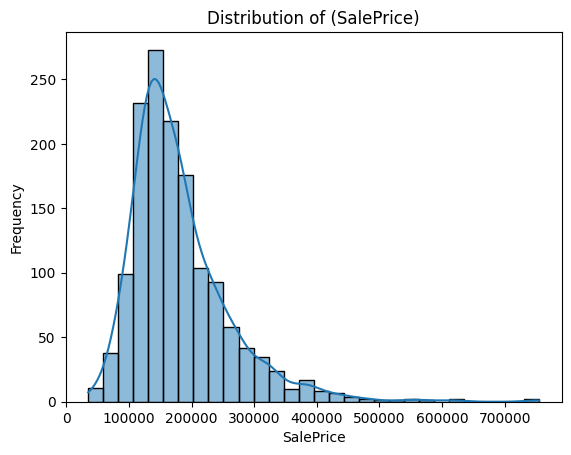

In [55]:
#Checking whether the output is balanced or not,since the data is Reggressor
sns.histplot(data1['SalePrice'], bins=30, kde=True)
plt.title("Distribution of (SalePrice)")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [56]:
#step 2: checked for skewness because the cnt is reggressor data
# (If skewness is |skew| < 1, no transformation is needed. If |skew| > 1, apply log or power transformation.)
from scipy.stats import skew
print(f"Skewness of SalePrice: {skew(data1['SalePrice']):.2f}")

Skewness of SalePrice: 1.88


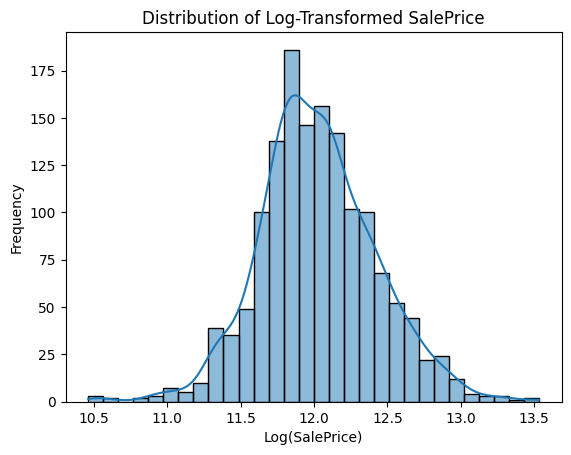

In [57]:


# Apply log transformation to SalePrice
data1['SalePrice'] = np.log1p(data1['SalePrice'])

# Plot the transformed distribution
sns.histplot(data1['SalePrice'], kde=True, bins=30)
plt.title('Distribution of Log-Transformed SalePrice')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()


In [58]:
print(f"Skewness of SalePrice: {skew(data1['SalePrice']):.2f}")

Skewness of SalePrice: 0.12


# Linear Regression

In [59]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression
# Initialise model
LR=LinearRegression()
# Train model with x_train and y_train
LR.fit(x_train,y_train)

LinearRegression()

In [60]:
# Make prediction /Test model
y_pred_LR=LR.predict(x_test)
y_pred_LR
y_pred_LRTrain=LR.predict(x_train)
y_pred_LRTrain

array([128712.2117975 , 184420.65419171,  82538.02986115, ...,
       124362.23310108, 173574.62241395, 208386.30586407])

In [61]:
# slopes/coefficients of x
LR.coef_

array([-4.61664478e+03, -8.61112540e+02,  9.39270084e+02,  4.88933838e+03,
        6.20631238e+02, -5.97551732e+03,  6.76540559e+02, -1.18969798e+03,
        2.40089973e+02,  2.87727830e+03, -9.32692417e+04, -8.33197929e+02,
       -2.16208753e+03, -1.11600016e+03, -1.56908680e+03,  1.57921789e+04,
        3.20189865e+03,  9.46952114e+02,  1.02378997e+03,  4.06626766e+03,
        2.72326973e+03, -1.55658381e+03,  2.27069633e+03, -1.73994809e+03,
        7.56603442e+03, -7.11357676e+02,  1.78254461e+03,  6.28050179e+03,
        6.86876401e+02,  5.53435022e+03, -6.67535934e+02,  1.44777738e+04,
        3.20540685e+03,  4.18304785e+03, -6.03036795e+01,  1.44271410e+02,
        2.17405439e+02, -9.35951688e+02,  1.80001860e+04,  2.35014498e+04,
        1.99595597e+02, -6.41506015e+03,  3.86945516e+02, -8.14460649e+02,
        1.76468083e+03,  9.94503355e+02, -4.64166504e+03, -2.36421923e+03,
        6.15620756e+03,  7.74059158e+03,  3.55005642e+03,  3.47325084e+03,
        2.60103437e+03,  

In [62]:
# intercept
LR.intercept_

np.float64(189938.44877822924)

# Evaluation

In [63]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score



MSE_LR=mean_squared_error(y_test,y_pred_LR)

MAE_LR=mean_absolute_error(y_test,y_pred_LR)

RMSE_LR=np.sqrt(MSE_LR)

R2_LR=r2_score(y_test,y_pred_LR)



print('MSE:',MSE_LR)

print('MAE:',MAE_LR)

print('RMSE:',RMSE_LR)

print('R2_score:',R2_LR)






MSE: 1346689050.3031163
MAE: 22198.479452368843
RMSE: 36697.26216358812
R2_score: 0.8244287121659489


In [64]:
adj_r2_LR=1-((1-0.824428712165949)*(292-1)/(292-71-1))
print('adj_r2:',adj_r2_LR)

adj_r2: 0.7677670692740508


In [65]:
# checking cross validation score

from sklearn.model_selection import cross_val_score
scores_LR=cross_val_score(LR,x,y,cv=3,scoring='r2')
print(scores_LR)
print('cross validation score',scores_LR.mean())
print('standard deviation',scores_LR.std())

[0.84178489 0.81349607 0.7874992 ]
cross validation score 0.8142600537088023
standard deviation 0.022168626159039133


#SVR

In [66]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(x_train,y_train)

SVR()

In [67]:
# Make prediction /Test model
y_pred_SVR=svr.predict(x_test)

In [68]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
MSE_SVR=mean_squared_error(y_test,y_pred_SVR)
MAE_SVR=mean_absolute_error(y_test,y_pred_SVR)
RMSE_SVR=np.sqrt(MSE_SVR)
R2_SVR=r2_score(y_test,y_pred_SVR)

print('MSE:',MSE_SVR)
print('MAE:',MAE_SVR)
print('RMSE:',RMSE_SVR)
print('R2_score:',R2_SVR)

MSE: 7855894080.381588
MAE: 59525.79605610359
RMSE: 88633.48171194443
R2_score: -0.024192957141846883


# Hyperparamter Tuning

In [69]:
from sklearn.model_selection import GridSearchCV

# Define SVR model

svr_ht = SVR()

# Define hyperparameter grid

param_grid = {

    'kernel': ['rbf', 'linear'],         # Try different kernels

    'C': [0.1, 1, 10, 100],              # Regularization

    'epsilon': [0.1, 1, 5, 10],          # Margin of tolerance

    'gamma': ['scale', 'auto']          # Kernel coefficient

}

# Setup GridSearchCV
grid_search = GridSearchCV(svr_ht, param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit on scaled training data
grid_search.fit(x_train, y_train)

# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_svr = grid_search.best_estimator_
# Predict on scaled test set
y_pred_svr_best = best_svr.predict(x_test)

Best Parameters: {'C': 100, 'epsilon': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [70]:
svr_ht = SVR(C= 100, epsilon=10, gamma='scale', kernel='linear')
svr_ht.fit(x_train, y_train)

SVR(C=100, epsilon=10, kernel='linear')

In [71]:
y_pred_SVR_ht=svr_ht.predict(x_test)

In [72]:
MSE_SVR_ht=mean_squared_error(y_test,y_pred_SVR_ht)
MAE_SVR_ht=mean_absolute_error(y_test,y_pred_SVR_ht)
RMSE_SVR_ht=np.sqrt(MSE_SVR_ht)
R2_SVR_ht=r2_score(y_test,y_pred_SVR_ht)

print('MSE:',MSE_SVR_ht)
print('MAE:',MAE_SVR_ht)
print('RMSE:',RMSE_SVR_ht)
print('R2_score:',R2_SVR_ht)

MSE: 1767296843.4404542
MAE: 20996.40076288185
RMSE: 42039.22981502461
R2_score: 0.7695930009098583


In [73]:
adj_r2_SVR=1-((1-0.7695930009098593)*(292-1)/(292-71-1))
print('adj_r2:',adj_r2_SVR)

adj_r2: 0.6952343784762229


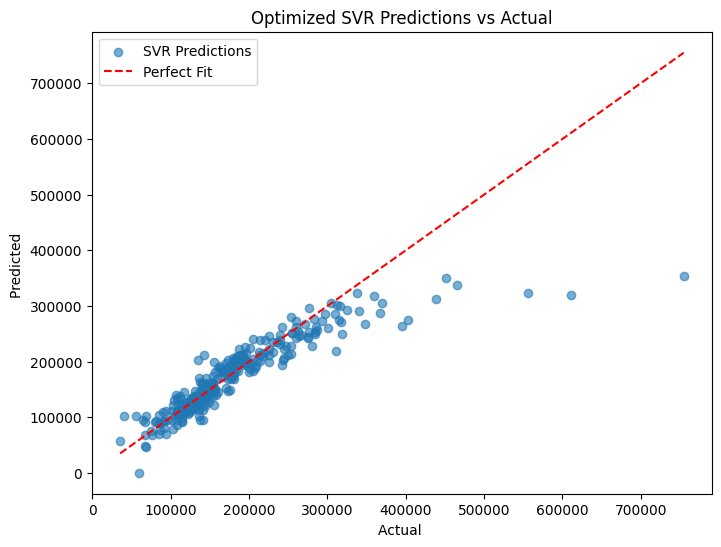

In [74]:
# Plot Actual vs Predicted (SVR)
plt.figure(figsize=(8, 6))
plt.scatter(y_test,y_pred_SVR_ht, alpha=0.6, label="SVR Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed', label="Perfect Fit")
plt.xlabel("Actual ")
plt.ylabel("Predicted ")
plt.title("Optimized SVR Predictions vs Actual")
plt.legend()
plt.show()

 # PCA

In [75]:
from sklearn.decomposition import PCA

# Apply PCA after splitting
pca = PCA(n_components=30)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [76]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)  # You can tune this
knn.fit(x_train_pca, y_train)
y_pred_KNN = knn.predict(x_test_pca)

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

MSE_KNN = mean_squared_error(y_test, y_pred_KNN)
MAE_KNN = mean_absolute_error(y_test, y_pred_KNN)
RMSE_KNN = np.sqrt(MSE_KNN)
R2_KNN = r2_score(y_test, y_pred_KNN)

print('MSE:', MSE_KNN)
print('MAE:', MAE_KNN)
print('RMSE:', RMSE_KNN)
print('R2 Score:', R2_KNN)

MSE: 1769642150.1041098
MAE: 25073.245205479452
RMSE: 42067.114829806305
R2 Score: 0.7692872372955992


In [78]:
n = len(y_test)  # Number of samples
k = 30  # PCA components = number of predictors

adj_r2 = 1 - ((1 - R2_KNN) * (n - 1)) / (n - k - 1)
print('Adjusted R²:', adj_r2)

Adjusted R²: 0.7427685289387715


# Random Forest Regressor

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train the basic Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

# Predictions
y_train_pred = rf.predict(x_train)
y_test_pred = rf.predict(x_test)

# Evaluation
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score



MSE_RF=mean_squared_error(y_test,y_test_pred )

MAE_RF=mean_absolute_error(y_test,y_test_pred )

RMSE_RF=np.sqrt(MSE_RF)

R2_test_RF=r2_score(y_test,y_test_pred )

R2_train_RF=r2_score(y_train,y_train_pred)

print('MSE:',MSE_RF)

print('MAE:',MAE_RF)

print('RMSE:',RMSE_RF)

print('R2_test_score:',R2_test_RF)

print('R2_train_score:',R2_train_RF)








MSE: 902222192.3079765
MAE: 18023.268116438358
RMSE: 30037.013704893776
R2_test_score: 0.8823749905887196
R2_train_score: 0.9779664824709718


In [80]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


Final Random Forest Model Performance:
Train R²: 0.946
Test R²: 0.847
Train RMSE: 17879.51
Test RMSE: 34225.41


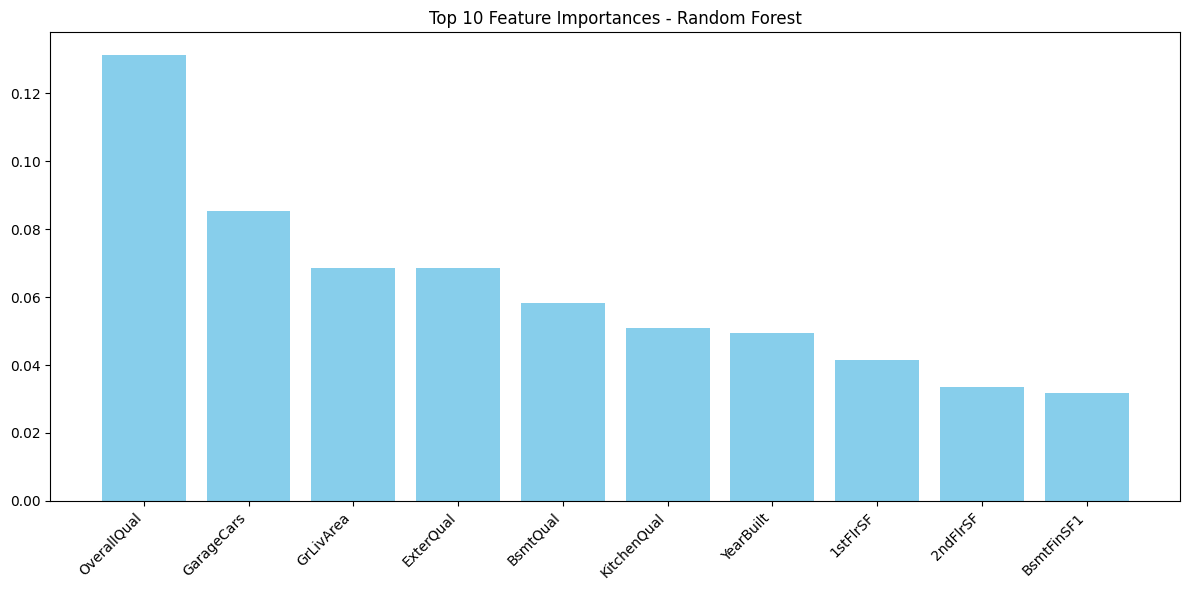

In [81]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Train Final Model with Best Hyperparameters
final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

final_rf.fit(x_train, y_train)

# Step 2: Predict
y_train_pred = final_rf.predict(x_train)
y_test_pred = final_rf.predict(x_test)

# Step 3: Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Final Random Forest Model Performance:")
print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

# Step 4: Feature Importance Plot
importances = final_rf.feature_importances_
feature_names = x.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Top 10 Feature Importances - Random Forest")
plt.bar(range(10), importances[indices[:10]], color='skyblue')
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


# XG Boost

In [82]:
pip install xgboost scikit-learn pandas numpy matplotlib

2) Scaling

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Standardize the feature variables
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

3) Train XGBoost model with default parameter

In [84]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Initialize XGBoost regressor with default parameters
xgb_default = xgb.XGBRegressor(max_depth=4,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42)

# Train the model on the training data
xgb_default.fit(x_train_scaled, y_train)

# Predict on training and testing data
y_train_pred_default = xgb_default.predict(x_train_scaled)
y_test_pred_default = xgb_default.predict(x_test_scaled)

# Evaluate the model
train_r2_default = r2_score(y_train, y_train_pred_default)
test_r2_default = r2_score(y_test, y_test_pred_default)
train_rmse_default =np.sqrt(mean_squared_error(y_train, y_train_pred_default))
test_rmse_default = np.sqrt(mean_squared_error(y_test, y_test_pred_default))

print(f"Default Model - Train R²: {train_r2_default:.3f}")
print(f"Default Model - Test R²: {test_r2_default:.3f}")
print(f"Default Model - Train RMSE: {train_rmse_default:.2f}")
print(f"Default Model - Test RMSE: {test_rmse_default:.2f}")

Default Model - Train R²: 0.990
Default Model - Test R²: 0.899
Default Model - Train RMSE: 7820.19
Default Model - Test RMSE: 27887.94


4) Visualize the actual vs predicted before tuning

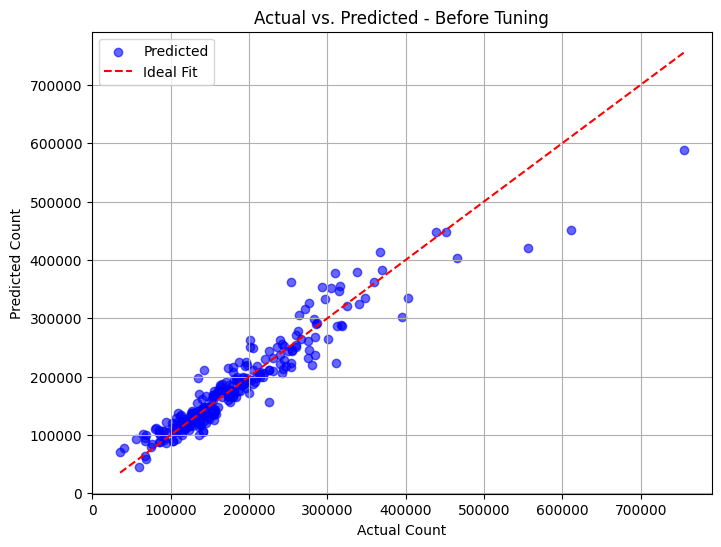

In [85]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_default, alpha=0.6, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs. Predicted - Before Tuning")
plt.legend()
plt.grid(True)
plt.show()

#HyperParameter tuning

In [86]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='r2', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(x_train_scaled, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


6) Train XGBoost model with best parameters

In [87]:
# Initialize XGBoost regressor with best parameters
xgb_best = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)

# Train the model on the training data
xgb_best.fit(x_train_scaled, y_train)

# Predict on training and testing data
y_train_pred_best = xgb_best.predict(x_train_scaled)
y_test_pred_best = xgb_best.predict(x_test_scaled)

# Evaluate the model
train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
train_rmse_best = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print(f"Tuned Model - Train R²: {train_r2_best:.3f}")
print(f"Tuned Model - Test R²: {test_r2_best:.3f}")
print(f"Tuned Model - Train RMSE: {train_rmse_best:.2f}")
print(f"Tuned Model - Test RMSE: {test_rmse_best:.2f}")

Tuned Model - Train R²: 0.994
Tuned Model - Test R²: 0.905
Tuned Model - Train RMSE: 6066.83
Tuned Model - Test RMSE: 27015.70


7) Visualize the actual vs predicted after tuning

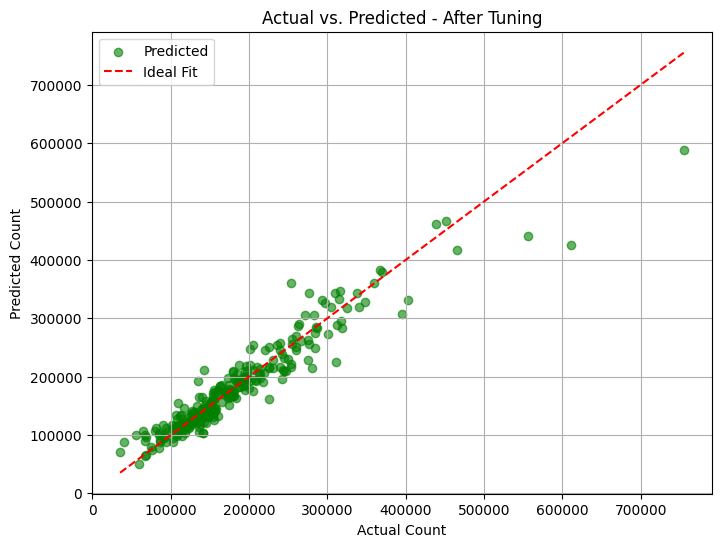

In [88]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_best, alpha=0.6, color='green', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs. Predicted - After Tuning")
plt.legend()
plt.grid(True)
plt.show()

In [89]:
 !pip install tabulate

In [90]:
from tabulate import tabulate

In [91]:
Table = [["LR", R2_LR,RMSE_LR],
        ["SVR", R2_SVR,RMSE_SVR],
        ["SVR_HT",R2_SVR_ht,RMSE_SVR_ht],
        ["KNN",R2_KNN,RMSE_KNN],
        ["Random_Forest",R2_test_RF,RMSE_RF,],
        ["Random_Forest(after HT)",test_r2,test_rmse],
        ["XGBoost",test_r2_default,test_rmse_default],
        ["XGBoost(after HT)",test_r2_best,test_rmse_best],
        ]





col_names1 = ["Algorithm","r2","rmse" ]

print(tabulate(Table, headers = col_names1, tablefmt = "fancy_grid"))

╒═════════════════════════╤═══════════╤═════════╕
│ Algorithm               │        r2 │    rmse │
╞═════════════════════════╪═══════════╪═════════╡
│ LR                      │  0.824429 │ 36697.3 │
├─────────────────────────┼───────────┼─────────┤
│ SVR                     │ -0.024193 │ 88633.5 │
├─────────────────────────┼───────────┼─────────┤
│ SVR_HT                  │  0.769593 │ 42039.2 │
├─────────────────────────┼───────────┼─────────┤
│ KNN                     │  0.769287 │ 42067.1 │
├─────────────────────────┼───────────┼─────────┤
│ Random_Forest           │  0.882375 │ 30037   │
├─────────────────────────┼───────────┼─────────┤
│ Random_Forest(after HT) │  0.847284 │ 34225.4 │
├─────────────────────────┼───────────┼─────────┤
│ XGBoost                 │  0.898604 │ 27887.9 │
├─────────────────────────┼───────────┼─────────┤
│ XGBoost(after HT)       │  0.904848 │ 27015.7 │
╘═════════════════════════╧═══════════╧═════════╛


In [91]:
Conclusion: XGBoost performs well